# NFL Prospect Bin Scoring — v1 (Proportion Scoring)

**Goal:** For each player, measure what proportion of their scouting language falls into three bins:
1. **Physical** — size, speed, athleticism, body traits
2. **Technique/Skills** — football-specific craft, stamina, energy
3. **Character/IQ** — effort, intelligence, decision-making, intangibles

**Method:** Keyword proportion scoring. After preprocessing, count how many tokens match each bin's keyword set, then divide by total matched tokens → three proportions that sum to 100%.

**Pipeline:**
1. Phrase stitching (curated, NFL-aware)
2. Stopword removal (custom, NFL-aware)
3. Lemmatization
4. Dictionary seeding (manual anchor keywords per bin)
5. Word2Vec expansion (grow keyword lists using corpus semantics)
6. Proportion scoring (keyword token counting)
7. Output: proportions + top matched keywords per player

In [ ]:
import pandas as pd
import numpy as np
import re
import json
from collections import Counter
from itertools import combinations

from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# ── Config ─────────────────────────────────────────────────────────────────────
W2V_DIM       = 100   # embedding dimensions
W2V_WINDOW    = 6     # context window
W2V_EPOCHS    = 30    # training passes
W2V_SG        = 1     # 1 = skip-gram
W2V_MIN_COUNT = 3     # ignore tokens appearing fewer than N times

SEED_TOPN      = 20   # W2V neighbors to retrieve per seed
SIM_THRESHOLD  = 0.35 # min cosine similarity for expansion candidates
MIN_SEED_COUNT = 2    # candidate must appear near >= N seeds to qualify
MAX_W2V_TERMS  = 25   # max W2V-expanded terms added per bin

TOP_TERMS_N = 5       # top matched keywords to surface per player-bin pair

BIN_NAMES = ['physical', 'technique', 'character']

FILTER_SPECIALISTS = True   # set False to include K, P, LS in all analysis

print('Imports OK')

## Section 1 — Load Data

In [ ]:
df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')

keep_cols = ['player_name', 'Pos_Group', 'position', 'grade', 'year',
             'made_it_contract', 'overview', 'strengths', 'weaknesses']
df = df[keep_cols].copy()

# Fill missing text — keep all rows, never drop
for col in ['overview', 'strengths', 'weaknesses']:
    df[col] = df[col].fillna('')

print(f'Players: {len(df)}')
print(f'Positions: {df["position"].nunique()} unique')
print(f'\nText coverage:')
for col in ['overview', 'strengths', 'weaknesses']:
    pct = (df[col].str.strip() != '').mean() * 100
    print(f'  {col:12s}: {pct:.1f}%')
# ── Specialist filter ───────────────────────────────────────────────────────────
if FILTER_SPECIALISTS:
    n_before = len(df)
    df = df[df['Pos_Group'] != 'SPECIAL'].reset_index(drop=True)
    print(f'Specialists removed: {n_before - len(df)}  (K, P, LS — Pos_Group=SPECIAL)')
    print(f'Players remaining  : {len(df)}')
else:
    print('Specialists included.')

## Section 2 — Preprocessing

Three steps applied in order:
1. **Phrase stitching** — replace multi-word NFL terms with underscore tokens *before* any tokenization, so `route running` → `route_running` survives as a single unit
2. **Stopword removal** — custom NFL-aware list; preserves football-relevant words like `high`, `low`, `hard`, `soft` that standard NLTK stops would remove
3. **Lemmatization** — reduces inflected forms to base (`rushing` → `rush`, `blocks` → `block`)

*PMI bigram discovery removed from v3 — curated phrases only, for simplicity and reproducibility.*

In [ ]:
# ── Curated compound NFL terms ─────────────────────────────────────────────────
# Sorted longest-first to prevent partial matches (trigrams before bigrams)
_CURATED_RAW = {
    # ── Trigrams & longer ──────────────────────────────────────────────────────
    'change of direction':      'change_of_direction',
    'low pad level':            'low_pad_level',
    'run after catch':          'run_after_catch',
    'yards after contact':      'yards_after_contact',
    'yards after catch':        'yards_after_catch',
    'run after contact':        'run_after_contact',
    'off the line':             'off_the_line',
    'off the ball':             'off_the_ball',
    'point of attack':          'point_of_attack',
    'get off the line':         'get_off_the_line',
    'read and react':           'read_and_react',
    'inside the box':           'inside_the_box',
    'stack and shed':           'stack_and_shed',
    'pass rush moves':          'pass_rush_moves',
    'tackles for loss':         'tackles_for_loss',
    'tackle for loss':          'tackle_for_loss',
    'setting the edge':         'setting_edge',
    'set the edge':             'setting_edge',
    'turn the corner':          'turn_the_corner',
    'flatten the arc':          'flatten_arc',
    'low to the ground':        'low_to_ground',
    'beat the punch':           'beat_the_punch',
    'grease the edge':          'grease_edge',
    'block take on':            'block_takeon',
    'block take-on':            'block_takeon',
    'knock back pop':           'knock_back_pop',
    'furious finish':           'furious_finish',
    'furious finishes':         'furious_finish',
    'make plays':               'play_making',
    'makes plays':              'play_making',
    'generates pressure':       'generate_pressure',
    'generate pressure':        'generate_pressure',
    'creates pressure':         'generate_pressure',
    'create pressure':          'generate_pressure',
    'north south':              'north_south',
    'north-south':              'north_south',
    'balanced base':            'balanced_base',
    'wide base':                'wide_base',
    'lower half power':         'lower_half',
    'explosive hips':           'explosive_hips',
    'burst of speed':           'burst_of_speed',
    'arm strength':             'arm_strength',
    'leg drive':                'leg_drive',
    'catch radius':             'catch_radius',
    'catching radius':          'catch_radius',
    'hip tightness':            'hip_tightness',
    'tight hips':               'hip_tightness',
    'high tightness':           'high_tightness',
    'hip bend':                 'hip_bend',
    'bend the edge':            'bend_edge',
    'edge bending':             'bend_edge',
    'lean frame':               'lean_frame',
    'lean build':               'lean_build',
    'thick frame':              'thick_frame',
    'raw speed':                'raw_speed',
    'raw power':                'raw_power',
    'raw athleticism':          'raw_athleticism',
    'long strides':             'long_strides',
    'short strides':            'short_strides',
    'straight line speed':      'straight_line_speed',
    'straight-line speed':      'straight_line_speed',
    'grip strength':            'grip_strength',
    # ── QB technique phrases ───────────────────────────────────────────────────
    'wrist flick':              'wrist_flick',
    'release point':            'release_point',
    'arm angles':               'arm_angles',
    'arm angle':                'arm_angles',
    'sees pressure':            'blitz_awareness',    # → character/IQ
    'reads pressure':           'blitz_awareness',
    'tight window':             'tight_windows',
    'tight windows':            'tight_windows',
    'drive throw':              'drive_throw',
    'drive throws':             'drive_throw',
    'touch throw':              'touch_pass',
    'cannon arm':               'cannon',
    'quick release':            'quick_delivery',
    'under pressure':           'pressure',
    'pocket passer':            'pocket_passer',
    # ── Bigrams ───────────────────────────────────────────────────────────────
    # Physical
    'lower half':               'lower_half',
    'lower body':               'lower_body',
    'upper body':               'upper_body',
    'playing speed':            'playing_speed',
    'change of pace':           'change_of_pace',
    'playing weight':           'playing_weight',
    'body weight':              'body_weight',
    'arm length':               'arm_length',
    # Technique — pass rush hand moves
    'violent club':             'violent_club',
    'club move':                'club_move',
    'spin move':                'spin_move',
    'swim move':                'swim_move',
    'speed rush':               'speed_rush',
    'counter move':             'counter_move',
    'rush move':                'rush_moves',
    'rush moves':               'rush_moves',
    'bull rush':                'bull_rush',
    'bull rusher':              'bull_rusher',
    'bull rushing':             'bull_rush',
    'push pocket':              'push_pocket',
    'collapse pocket':          'collapse_pocket',
    'attack angle':             'attack_angle',
    'rush plan':                'rush_plan',
    # Technique — run defense / LB
    'run support':              'run_support',
    'run stopper':              'run_stopper',
    'setting edge':             'setting_edge',
    'run fits':                 'run_fits',
    'run fit':                  'run_fits',
    'run defense':              'run_defense',
    'pursuit angle':            'pursuit_angle',
    'wrap up':                  'wrap_up',
    'sure tackler':             'sure_tackler',
    'secure tackler':           'sure_tackler',
    'downhill trigger':         'downhill_trigger',
    # Technique — OL
    'pass sets':                'pass_sets',
    'arm extension':            'arm_extension',
    'drive blocking':           'drive_blocking',
    'reach blocking':           'reach_blocking',
    'zone blocker':             'zone_blocker',
    'gap blocker':              'gap_blocker',
    'road grader':              'road_grader',
    # Technique — hands / leverage
    'active hands':             'active_hands',
    'hand usage':               'hand_usage',
    'hip sink':                 'hip_sink',
    'pocket presence':          'pocket_presence',
    'edge setter':              'edge_setter',
    # Technique — coverage / DB
    'press technique':          'press_technique',
    'off coverage':             'off_coverage',
    'trail technique':          'trail_technique',
    'man to man':               'man_coverage',
    'zone scheme':              'zone_coverage',
    'zone drops':               'zone_drops',
    're route':                 're_route',
    're-route':                 're_route',
    'break on ball':            'break_on_ball',
    # Technique — WR/TE/RB receiving
    'high point':               'high_point',
    'contested catch':          'contested_catch',
    'contested catches':        'contested_catch',
    'post up':                  'post_up',
    'frame up':                 'frame_up',
    'separation quickness':     'separation_quickness',
    # Character / IQ
    'football intelligence':    'football_intelligence',
    'mental toughness':         'mental_toughness',
    'high effort':              'high_effort',
    'off field':                'off_field',
    'practice habits':          'practice_habits',
    'film room':                'film_room',
    'football character':       'football_character',
    'blitz awareness':          'blitz_awareness',
    'pocket awareness':         'pocket_awareness',
    'eye level':                'eye_level',
    'ultra competitive':        'ultra_competitive',
    # Existing bigrams (unchanged)
    'pass rush':                'pass_rush',
    'pass rusher':              'pass_rusher',
    'pass protection':          'pass_protection',
    'pass coverage':            'pass_coverage',
    'pad level':                'pad_level',
    'press coverage':           'press_coverage',
    'man coverage':             'man_coverage',
    'zone coverage':            'zone_coverage',
    'zone coverages':           'zone_coverages',
    'ball skills':              'ball_skills',
    'ball hawk':                'ball_hawk',
    'ball hawking':             'ball_hawking',
    'ball carrier':             'ball_carrier',
    'ball carriers':            'ball_carriers',
    'body control':             'body_control',
    'contact balance':          'contact_balance',
    'closing speed':            'closing_speed',
    'lateral quickness':        'lateral_quickness',
    'quick twitch':             'quick_twitch',
    'high motor':               'high_motor',
    'first step':               'first_step',
    'get off':                  'get_off',
    'hand fighting':            'hand_fighting',
    'hand strength':            'hand_strength',
    'hand placement':           'hand_placement',
    'strong hands':             'strong_hands',
    'soft hands':               'soft_hands',
    'heavy hands':              'heavy_hands',
    'block shedding':           'block_shedding',
    'anchor strength':          'anchor_strength',
    'route running':            'route_running',
    'run blocking':             'run_blocking',
    'open field':               'open_field',
    'red zone':                 'red_zone',
    'second level':             'second_level',
    'hip flexibility':          'hip_flexibility',
    'short area':               'short_area',
    'three down':               'three_down',
    'top end':                  'top_end',
    'two gap':                  'two_gap',
    'one gap':                  'one_gap',
    'two gapping':              'two_gapping',
    'one gapping':              'one_gapping',
    'snap count':               'snap_count',
    'football iq':              'football_iq',
    'film study':               'film_study',
    'work ethic':               'work_ethic',
    'locker room':              'locker_room',
    'decision making':          'decision_making',
    'play making':              'play_making',
    'field vision':             'field_vision',
    'play recognition':         'play_recognition',
    'pre snap':                 'pre_snap',
    'post snap':                'post_snap',
    'game ready':               'game_ready',
    'hard worker':              'hard_worker',
    'arm_length':               'arm_length',
    'functional strength':      'functional_strength',
    'tackling form':            'tackling_form',
    'processing speed':         'processing_speed',
    'eye discipline':           'eye_discipline',
    'spatial awareness':        'spatial_awareness',
    'route progressions':       'route_progressions',
}

CURATED_PHRASE_MAP = dict(
    sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True)
)
print(f'Curated phrases: {len(CURATED_PHRASE_MAP)}')

# ── NFL-aware stop words ────────────────────────────────────────────────────────
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great',
    'up', 'down', 'off', 'out', 'over', 'through', 'above', 'below',
    'hand', 'hands', 'back', 'field', 'ball'
}

CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside',
    'starter', 'backup', 'senior', 'junior', 'cb', 'rb', 'wr', 'qb'
}

_base = set(stopwords.words('english'))
NFL_STOPWORDS = (_base - KEEP_WORDS) | CUSTOM_STOPS

print(f'Base NLTK stops  : {len(_base)}')
print(f'Un-stopped        : {len(KEEP_WORDS & _base)}  (kept from NLTK list)')
print(f'Custom added      : {len(CUSTOM_STOPS)}')
print(f'Final stop list   : {len(NFL_STOPWORDS)}')


In [ ]:
lemmatizer = WordNetLemmatizer()

def nfl_preprocess(text: str, phrase_map: dict = CURATED_PHRASE_MAP) -> str:
    """NFL-aware preprocessing: normalize → stitch → clean → filter → lemmatize."""
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'[-\u2013\u2014]', ' ', text)       # normalize all dash variants
    for phrase, token in phrase_map.items():              # curated phrase stitching
        text = text.replace(phrase, token)
    text = re.sub(r'[^a-z_\s]', ' ', text)              # keep letters + underscores only
    tokens = text.split()
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)

# Apply to each section
df['strengths_clean']  = df['strengths'].apply(nfl_preprocess)
df['overview_clean']   = df['overview'].apply(nfl_preprocess)
df['weaknesses_clean'] = df['weaknesses'].apply(nfl_preprocess)

# Combine all sections into one token list per player
df['all_text']   = (df['overview_clean'] + ' ' +
                    df['strengths_clean'] + ' ' +
                    df['weaknesses_clean']).str.strip()
df['all_tokens'] = df['all_text'].apply(str.split)

# Section-specific token lists (used for per-section scoring in Section 5)
df['strengths_tokens']  = df['strengths_clean'].apply(str.split)
df['weaknesses_tokens'] = df['weaknesses_clean'].apply(str.split)

lengths = df['all_tokens'].apply(len)
print(f'Preprocessing complete.')
print(f'Tokens per player — median: {lengths.median():.0f},  min: {lengths.min()},  max: {lengths.max()}')

## Section 3 — Word2Vec Training

W2V is trained on all player text. Its **sole role** in this pipeline is **vocabulary expansion** in the next section — it identifies which corpus terms cluster near our manual seed words, extending keyword lists beyond what we could hand-curate.

W2V output is never used for scoring. Scoring is done by simple keyword token counting.

In [158]:
sentences = df['all_tokens'].tolist()

w2v = Word2Vec(
    sentences   = sentences,
    vector_size = W2V_DIM,
    window      = W2V_WINDOW,
    epochs      = W2V_EPOCHS,
    sg          = W2V_SG,
    min_count   = W2V_MIN_COUNT,
    workers     = 4,
    seed        = 42,
)

print(f'W2V trained.  Vocab size: {len(w2v.wv)} tokens')

# Quick sanity — check a few seeds are in vocab
spot_check = ['explosive', 'footwork', 'football_iq', 'route_running', 'toughness']
for t in spot_check:
    status = '✓' if t in w2v.wv else '✗ MISSING'
    print(f'  {status}  {t}')

W2V trained.  Vocab size: 7853 tokens
  ✓  explosive
  ✓  footwork
  ✓  football_iq
  ✓  route_running
  ✓  toughness


## Section 4 — Dictionary Seeding & W2V Expansion

**Step 1 — Anchor seeds:** small, unambiguous, high-frequency keyword lists per bin.
These are hand-curated to be clearly representative of each bin with minimal cross-bin overlap.

**Step 2 — W2V expansion:** for each seed, retrieve nearest neighbors from the trained corpus.
Keep candidates that appear near ≥ 2 seeds (multi-seed confirmation reduces noise).

**Step 3 — Manual additions:** stitched compound phrases (`route_running`, `football_iq`) and
domain-critical terms that W2V may miss due to low frequency or stitching.

**Step 4 — Overlap check:** flag any term appearing in multiple bins and resolve.

In [159]:
# ── Anchor seeds — minimal, unambiguous, high-frequency ────────────────────────
# These seed W2V expansion. Keep lists tight and non-overlapping.
ANCHOR_SEEDS = {
    'physical': [
        'explosive', 'burst', 'speed', 'acceleration', 'first_step', 'get_off',
        'change_of_direction', 'agility', 'frame', 'size', 'strength',
        'power', 'athletic', 'physical', 'twitch',
    ],
    'technique': [
        'technique', 'footwork', 'leverage', 'pad_level', 'mechanics',
        'route_running', 'pass_protection', 'hand_fighting', 'block_shedding',
        'anchor_strength', 'pass_rush', 'blocking', 'tackling', 'coverage',
    ],
    'character': [
        'effort', 'motor', 'high_motor', 'relentless', 'competitive',
        'toughness', 'instinct', 'awareness', 'intelligence', 'football_iq',
        'coachable', 'discipline', 'leadership', 'work_ethic', 'recognition',
    ],
}

# Vocab check — flag missing seeds so we can adjust if needed
print('Anchor seed vocab coverage:')
for bin_name, seeds in ANCHOR_SEEDS.items():
    in_vocab = [s for s in seeds if s in w2v.wv]
    missing  = [s for s in seeds if s not in w2v.wv]
    print(f'  {bin_name:12s}: {len(in_vocab)}/{len(seeds)} in W2V vocab'
          + (f'  — MISSING: {missing}' if missing else ''))

Anchor seed vocab coverage:
  physical    : 15/15 in W2V vocab
  technique   : 12/14 in W2V vocab  — MISSING: ['mechanics', 'block_shedding']
  character   : 15/15 in W2V vocab


In [160]:
def expand_bin(seeds: list, model: Word2Vec,
               topn: int = SEED_TOPN,
               threshold: float = SIM_THRESHOLD) -> pd.DataFrame:
    """
    For each seed in W2V vocab, retrieve topN nearest neighbors.
    Aggregate by: how many seeds each candidate appears near (seed_count)
    and average similarity. Returns sorted DataFrame of candidates.
    """
    candidate_scores: dict = {}
    for seed in seeds:
        if seed not in model.wv:
            continue
        for word, sim in model.wv.most_similar(seed, topn=topn):
            if sim >= threshold and word not in seeds:
                candidate_scores.setdefault(word, []).append(sim)

    if not candidate_scores:
        return pd.DataFrame(columns=['term', 'seed_count', 'avg_sim', 'max_sim'])

    rows = [{'term': w,
             'seed_count': len(s),
             'avg_sim': round(float(np.mean(s)), 3),
             'max_sim': round(float(np.max(s)),  3)}
            for w, s in candidate_scores.items()]
    return (pd.DataFrame(rows)
              .sort_values(['seed_count', 'avg_sim'], ascending=False)
              .reset_index(drop=True))

# Run expansion for all three bins
BIN_LEXICONS = {}
for bin_name, seeds in ANCHOR_SEEDS.items():
    BIN_LEXICONS[bin_name] = expand_bin(seeds, w2v)

print('W2V expansion complete.')
print()
for bin_name, lex in BIN_LEXICONS.items():
    hc = lex[lex['seed_count'] >= MIN_SEED_COUNT]
    print(f'{bin_name} — {len(hc)} high-confidence expansions (seed_count >= {MIN_SEED_COUNT}):')
    print(hc.head(MAX_W2V_TERMS).to_string(index=False))
    print()

W2V expansion complete.

physical — 44 high-confidence expansions (seed_count >= 2):
               term  seed_count  avg_sim  max_sim
         short_area           4    0.594    0.681
          quickness           3    0.647    0.677
            top_end           3    0.621    0.753
           reactive           3    0.608    0.671
            redmond           3    0.577    0.585
         accelerate           3    0.575    0.667
           fluidity           3    0.574    0.604
               mass           3    0.565    0.619
          sheffield           3    0.553    0.590
            density           3    0.549    0.566
            lateral           2    0.675    0.687
        athleticism           2    0.634    0.638
            closing           2    0.627    0.699
              juice           2    0.609    0.632
             length           2    0.588    0.595
               gear           2    0.587    0.602
straight_line_speed           2    0.581    0.616
          tough

In [161]:
# ── Manual additions ───────────────────────────────────────────────────────────
# Philosophy: if a word appears in a scouting report and has a clear athletic
# meaning, it should have a bin. Be inclusive rather than conservative.
MANUAL_ADDITIONS = {
    'physical': [
        # Size & measurement
        # NOTE: bare 'weight' removed — too ambiguous. Use 'playing_weight'/'body_weight'.
        'height', 'length', 'wingspan', 'build', 'size',
        'big', 'tall', 'wide', 'lean', 'heavy', 'mass', 'thick', 'long',
        'frame', 'arm_length', 'high_waisted', 'dense', 'lanky', 'stout',
        'playing_weight', 'body_weight',
        'lean_frame', 'lean_build', 'thick_frame',
        # Body region
        'lower_half', 'lower_body', 'upper_body',
        'balanced_base', 'wide_base', 'low_to_ground',
        # Speed / movement
        'speed', 'quickness', 'burst', 'acceleration',
        'lateral_quickness', 'closing_speed', 'top_end', 'quick_twitch',
        'body_control', 'fluidity', 'fluid', 'flexible', 'flexibility',
        'playing_speed', 'change_of_pace', 'burst_of_speed',
        'straight_line_speed', 'long_strides', 'short_strides',
        'north_south', 'wiggle', 'leaper',
        # Hip / bend
        'hip_bend', 'hip_tightness', 'high_tightness', 'explosive_hips',
        'hip_flexibility', 'bend_edge',
        # Athleticism
        'natural', 'raw', 'powerful', 'fast', 'athlete', 'dynamic',
        'shifty', 'explosion', 'vertical', 'leap', 'projectable',
        'explosiveness', 'twitchy', 'functional_strength', 'displacement',
        # Arm / velocity
        'arm', 'velocity', 'arm_strength', 'cannon',
        'arm_length', 'grip_strength', 'leg_drive', 'catch_radius',
        'raw_speed', 'raw_power', 'raw_athleticism',
        # Rarity
        'rare', 'specimen', 'elite', 'scouts_dream',
    ],
    'technique': [
        # Hands (very common in scouting, always technique)
        'hand', 'hands',
        # QB craft — the most under-represented category
        'throw', 'throws', 'release', 'delivery', 'accuracy', 'timing',
        'pocket', 'footwork', 'drop', 'platform', 'touch', 'trajectory',
        'wrist_flick', 'dropback', 'quick_delivery', 'pocket_movement',
        'ball_placement', 'touch_pass', 'timing_routes',
        'pocket_presence', 'arm_angles', 'checkdown',
        # Pressure (generating or handling — technique in >90% of scouting usage)
        'pressure',
        # Pass rush — hand moves
        'bull_rush', 'bull_rusher', 'spin_move', 'swim_move',
        'club_move', 'violent_club', 'speed_rush', 'counter_move',
        'rush_moves', 'pass_rush_moves', 'beat_the_punch', 'grease_edge',
        'turn_the_corner', 'flatten_arc', 'attack_angle', 'rush_plan',
        'push_pocket', 'collapse_pocket', 'knock_back_pop', 'furious_finish',
        'generate_pressure',
        # Run defense / LB / edge
        'run_support', 'run_stopper', 'inside_the_box', 'setting_edge',
        'run_fits', 'run_defense', 'tackle_for_loss', 'tackles_for_loss',
        'sack', 'sacks', 'blows_up', 'stack_and_shed', 'downhill',
        'pursuit_angle', 'wrap_up', 'sure_tackler', 'tackler',
        'downhill_trigger', 'edge_setter', 'block_takeon',
        # OL
        'pass_sets', 'arm_extension', 'drive_blocking', 'reach_blocking',
        'zone_blocker', 'gap_blocker', 'road_grader',
        # Hands / leverage
        'active_hands', 'hand_usage', 'hip_sink', 'punch',
        # Coverage / DB
        'press_technique', 'off_coverage', 'trail_technique',
        'zone_drops', 're_route', 'break_on_ball',
        # WR / TE / RB receiving
        'separation', 'high_point', 'contested_catch', 'post_up',
        'frame_up', 'separation_quickness',
        # Existing compound craft terms
        'pass_rush', 'pass_rusher', 'pass_protection', 'route_running',
        'run_blocking', 'block_shedding', 'anchor_strength', 'hand_fighting',
        'press_coverage', 'zone_coverage', 'man_coverage', 'low_pad_level',
        'point_of_attack', 'ball_skills', 'soft_hands', 'heavy_hands',
        'strong_hands', 'hand_placement', 'shed', 'leveraged', 'mirror',
        # Vision & processing (on-field real-time)
        'vision', 'field_vision', 'spatial_awareness', 'anticipation',
        'eye_discipline', 'read_and_react', 'processing_speed', 'route_progressions',
        # RB / skill specifics
        'contact_balance', 'run_after_catch', 'yards_after_catch',
        'yards_after_contact', 'run_after_contact',
        'uncover', 'uncovering', 'get_off_the_line',
        # DB / defensive technique
        'pedal', 'backpedal', 'wrapping', 'tackling_form', 'zone_coverages',
        # Stamina / conditioning
        'stamina', 'endurance', 'conditioning', 'energy', 'snap_count', 'three_down',
        # Craft descriptors
        'precise', 'sound', 'polished', 'refined', 'crisp', 'clean',
        'skilled', 'technical', 'fundamental', 'mechanics', 'craft',
        'skill', 'execution', 'assignment', 'disruptive', 'penetration',
    ],
    'character': [
        # Effort & motor
        'high_motor', 'work_ethic', 'hard_worker', 'hustle', 'grit',
        'relentless', 'compete', 'pursuit', 'intensity', 'passion',
        'competitive_toughness', 'alpha', 'high_effort', 'ultra_competitive',
        'fearless', 'tough', 'toughness',
        # Mental recognition / IQ
        'football_iq', 'football_intelligence', 'decision_making',
        'play_recognition', 'pre_snap', 'post_snap',
        'cerebral', 'smart', 'savvy', 'diagnose', 'read',
        'instinct', 'play_making', 'mental_toughness',
        'blitz_awareness', 'pocket_awareness', 'eye_level',
        'downhill_trigger', 'trigger',
        # Patience / poise
        'patient', 'patience', 'poised', 'poise', 'calm',
        # Character markers
        'leadership', 'accountable', 'driven', 'focused', 'committed',
        'workhorse', 'coachable', 'film_study', 'film_room', 'locker_room',
        'captain', 'consistent', 'reliable', 'dependable', 'composure',
        'mature', 'dedicated', 'trustworthy', 'selfless', 'teammate',
        'red_flag', 'off_field', 'practice_habits', 'football_character',
    ],
}

# ── Build final keyword sets ────────────────────────────────────────────────────
KEYWORD_SETS = {}
W2V_CONTRIBUTIONS = {}

for bin_name in BIN_NAMES:
    seeds     = set(ANCHOR_SEEDS[bin_name])
    lex       = BIN_LEXICONS[bin_name]
    w2v_terms = set(lex[lex['seed_count'] >= MIN_SEED_COUNT]
                       .head(MAX_W2V_TERMS)['term'])
    manual    = set(MANUAL_ADDITIONS[bin_name])

    KEYWORD_SETS[bin_name]      = seeds | w2v_terms | manual
    W2V_CONTRIBUTIONS[bin_name] = w2v_terms - seeds - manual

print('Final keyword set sizes:')
for bin_name in BIN_NAMES:
    n_seed   = len(ANCHOR_SEEDS[bin_name])
    n_w2v    = len(W2V_CONTRIBUTIONS[bin_name])
    n_manual = len(MANUAL_ADDITIONS[bin_name])
    n_total  = len(KEYWORD_SETS[bin_name])
    print(f'  {bin_name:12s}: {n_total} terms  '
          f'(seeds: {n_seed}, W2V-only: {n_w2v}, manual: {n_manual})')

# ── Overlap check ───────────────────────────────────────────────────────────────
print()
found_overlap = False
for b1, b2 in combinations(BIN_NAMES, 2):
    overlap = KEYWORD_SETS[b1] & KEYWORD_SETS[b2]
    if overlap:
        print(f'⚠  Overlap {b1} ∩ {b2}: {sorted(overlap)}')
        found_overlap = True
if not found_overlap:
    print('✓  No keyword overlap between bins.')


Final keyword set sizes:
  physical    : 115 terms  (seeds: 15, W2V-only: 18, manual: 88)
  technique   : 177 terms  (seeds: 14, W2V-only: 18, manual: 153)
  character   : 94 terms  (seeds: 15, W2V-only: 22, manual: 65)

⚠  Overlap physical ∩ technique: ['contact_balance']
⚠  Overlap physical ∩ character: ['toughness']
⚠  Overlap technique ∩ character: ['anticipation', 'downhill_trigger']


## Section 5 — Proportion Scoring

For each player:
1. Iterate over their preprocessed token list
2. Count how many tokens match each bin's keyword set
3. Divide by total matched tokens → three proportions summing to 100%
4. Record which specific keywords drove each bin (top N by frequency)

Players with zero keyword matches (empty/very short reports) receive 0.0 for all bins.
Their `total_matched` column will be 0, making them easy to filter downstream.

In [162]:
def score_player(tokens: list, keyword_sets: dict, top_n: int = TOP_TERMS_N) -> dict:
    """
    Count keyword matches per bin and return proportions + top matched terms.

    Parameters
    ----------
    tokens       : preprocessed token list for one player
    keyword_sets : {bin_name: set of keywords}
    top_n        : how many top matched keywords to return per bin

    Returns
    -------
    dict with _pct, _count, and _top_terms columns for each bin,
    plus total_matched
    """
    counts = {b: 0 for b in keyword_sets}
    hits   = {b: [] for b in keyword_sets}

    for token in tokens:
        for bin_name, keywords in keyword_sets.items():
            if token in keywords:
                counts[bin_name] += 1
                hits[bin_name].append(token)

    total = sum(counts.values())
    result = {'total_matched': total}

    for bin_name in keyword_sets:
        pct = counts[bin_name] / total if total > 0 else 0.0
        top = ', '.join(t for t, _ in Counter(hits[bin_name]).most_common(top_n))
        result[f'{bin_name}_pct']       = round(pct, 4)
        result[f'{bin_name}_count']     = counts[bin_name]
        result[f'{bin_name}_top_terms'] = top

    return result

# ── Combined scoring (all sections) ────────────────────────────────────────────
score_records = df['all_tokens'].apply(lambda toks: score_player(toks, KEYWORD_SETS))
scores_df     = pd.DataFrame(score_records.tolist())

ID_COLS = ['player_name', 'Pos_Group', 'position', 'grade', 'year', 'made_it_contract']
df_result = pd.concat([df[ID_COLS].reset_index(drop=True), scores_df], axis=1)

# ── Section-specific scoring (strengths / weaknesses) ──────────────────────────
# Adds str_* and wk_* prefixed columns so the temporal viz can be toggled
for token_col, prefix in [('strengths_tokens', 'str'), ('weaknesses_tokens', 'wk')]:
    sec_records = df[token_col].apply(lambda toks: score_player(toks, KEYWORD_SETS))
    sec_df = pd.DataFrame(sec_records.tolist())
    sec_df = sec_df.rename(columns={c: f'{prefix}_{c}' for c in sec_df.columns})
    df_result = pd.concat([df_result, sec_df.reset_index(drop=True)], axis=1)

print(f'Scored {len(df_result)} players.')
print(f'\nCombined columns : {[c for c in df_result.columns if c.endswith("_pct") and not c.startswith(("str_","wk_"))]}')
print(f'Strengths columns: {[c for c in df_result.columns if c.startswith("str_") and c.endswith("_pct")]}')
print(f'Weakness columns : {[c for c in df_result.columns if c.startswith("wk_")  and c.endswith("_pct")]}')
print(f'\nSample (3 players):')
display_cols = ID_COLS + ['physical_pct', 'technique_pct', 'character_pct', 'total_matched']
print(df_result[display_cols].head(3).to_string(index=False))

Scored 7173 players.

Combined columns : ['physical_pct', 'technique_pct', 'character_pct']
Strengths columns: ['str_physical_pct', 'str_technique_pct', 'str_character_pct']
Weakness columns : ['wk_physical_pct', 'wk_technique_pct', 'wk_character_pct']

Sample (3 players):
      player_name Pos_Group position  grade  year made_it_contract  physical_pct  technique_pct  character_pct  total_matched
Jonathan Crompton        QB       QB    5.0  2010              NaN           0.0            0.0            0.0              0
   Ramon Harewood        OL       OT    5.0  2010              NaN           0.0            0.0            0.0              0
    Mickey Shuler        TE       TE    5.0  2010            False           0.0            0.0            0.0              0


## Section 6 — Validation & Spot Checks

In [163]:
def player_report(name: str) -> None:
    """Print a detailed scoring breakdown for a named player."""
    matches = df_result[df_result['player_name'].str.lower() == name.lower()]
    if matches.empty:
        matches = df_result[df_result['player_name'].str.lower().str.contains(name.lower())]
    if matches.empty:
        print(f'Player "{name}" not found.')
        return

    row = matches.iloc[0]
    sep  = '=' * 55
    dash = '-' * 55
    print(sep)
    print(f'  {row["player_name"]}  |  {row["position"]}  |  Grade: {row["grade"]}')
    print(f'  Contract reached: {row["made_it_contract"]}')
    print(dash)
    for b in BIN_NAMES:
        pct   = row[f'{b}_pct'] * 100
        cnt   = row[f'{b}_count']
        terms = row[f'{b}_top_terms'] or '—'
        bar   = chr(9608) * int(pct / 5)
        print(f'  {b:12s} {pct:5.1f}%  {bar:<20s}  ({cnt} tokens)')
        print(f'               -> {terms}')
    print(dash)
    print(f'  total matched tokens: {row["total_matched"]}')
    print()

# Spot-check a handful of players
sample_names = df_result['player_name'].sample(5, random_state=42).tolist()
for name in sample_names:
    player_report(name)

  Joe Lowery  |  G  |  Grade: 5.6
  Contract reached: False
-------------------------------------------------------
  physical      44.4%  ████████              (12 tokens)
               -> athleticism, arm, reactive, athletic, power
  technique     40.7%  ████████              (11 tokens)
               -> pass_protection, block, hand, point_of_attack, timing
  character     14.8%  ██                    (4 tokens)
               -> effort, competitive, consistent
-------------------------------------------------------
  total matched tokens: 27

  Ha Ha Clinton-Dix  |  FS  |  Grade: 6.7
  Contract reached: False
-------------------------------------------------------
  physical      47.4%  █████████             (9 tokens)
               -> lean, athletic, physical, size, length
  technique     52.6%  ██████████            (10 tokens)
               -> coverage, skill, tackling, read_and_react, hand
  character      0.0%                        (0 tokens)
               -> —
----------

In [164]:
# ── Average bin proportions by position group ──────────────────────────────────
pos_summary = (
    df_result
    .groupby('Pos_Group')[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .rename(columns={
        'physical_pct':  'Physical %',
        'technique_pct': 'Technique %',
        'character_pct': 'Character %',
    })
    .sort_values('Physical %', ascending=False)
)

print('Average bin proportions by position group:')
print(pos_summary.to_string())

Average bin proportions by position group:
           Physical %  Technique %  Character %
Pos_Group                                      
RB               49.2         30.2         11.4
EDGE             45.0         36.2         11.8
WR               44.1         39.2          7.5
DT               42.9         40.6         10.0
OL               42.3         42.0          7.4
TE               39.1         43.5          8.1
DB               38.0         38.1         13.1
LB               36.5         33.7         18.8
QB               25.9         47.4         16.6


In [165]:
# ── Coverage diagnostics ───────────────────────────────────────────────────────
zero_match = df_result['total_matched'] == 0
low_match  = df_result['total_matched'].between(1, 4)

print(f'Players with 0 keyword matches : {zero_match.sum()}')
print(f'Players with 1-4 matches       : {low_match.sum()}  (low-coverage, treat with caution)')
print(f'Players with ≥5 matches        : {(df_result["total_matched"] >= 5).sum()}')

if zero_match.sum() > 0:
    print('\nZero-match players (empty/very short reports):')
    print(df_result[zero_match][['player_name', 'position', 'grade']].to_string(index=False))

# Score distribution
print('\nBin score distribution (% of scouting language):')
print(df_result[['physical_pct', 'technique_pct', 'character_pct']]
      .multiply(100)
      .describe()
      .round(1)
      .to_string())

Players with 0 keyword matches : 653
Players with 1-4 matches       : 4  (low-coverage, treat with caution)
Players with ≥5 matches        : 6516

Zero-match players (empty/very short reports):
                  player_name position  grade
            Jonathan Crompton       QB   5.00
               Ramon Harewood       OT   5.00
                Mickey Shuler       TE   5.00
                     Joe Webb       QB   5.00
                Phillip Adams       DB    NaN
               Lucien Antoine        S    NaN
              Terrence Austin       WR    NaN
                 Danny Batten       DE    NaN
                  Ciron Black       OT    NaN
              Cornelius Brown       CB    NaN
                Jarrett Brown       QB    NaN
                 Stevie Brown       DB    NaN
               Jorrick Calvin       DB    NaN
                 Daryll Clark       QB    NaN
               Ryan D'Imperio       LB    NaN
                   Ray Fisher       DB    NaN
                 David G

## Section 7 — Export

In [166]:
# ── Main scores CSV ────────────────────────────────────────────────────────────
out_path = '../data/processed/bin_scores_v1.csv'
df_result.to_csv(out_path, index=False)
print(f'✓ Scores saved  →  {out_path}')
print(f'  Shape: {df_result.shape}')

# ── Keyword lexicon reference CSV ───────────────────────────────────────────────
# Records every term in each bin's final keyword set, tagged by source
lex_rows = []
for bin_name in BIN_NAMES:
    lex_df_idx = BIN_LEXICONS[bin_name].set_index('term') if len(BIN_LEXICONS[bin_name]) else pd.DataFrame()
    for term in sorted(KEYWORD_SETS[bin_name]):
        if term in ANCHOR_SEEDS[bin_name]:
            source = 'seed'
        elif term in MANUAL_ADDITIONS[bin_name]:
            source = 'manual'
        else:
            source = 'w2v'
        w2v_sim = (round(float(lex_df_idx.loc[term, 'avg_sim']), 3)
                   if (len(lex_df_idx) > 0 and term in lex_df_idx.index) else None)
        lex_rows.append({'bin': bin_name, 'term': term,
                         'source': source, 'w2v_avg_sim': w2v_sim})

lex_out = pd.DataFrame(lex_rows).sort_values(['bin', 'source', 'term'])
lex_path = '../data/processed/bin_lexicons_v1.csv'
lex_out.to_csv(lex_path, index=False)
print(f'✓ Lexicons saved →  {lex_path}')

print(f'\nLexicon summary:')
print(lex_out.groupby(['bin', 'source'])['term'].count().to_string())

✓ Scores saved  →  ../data/processed/bin_scores_v1.csv
  Shape: (7173, 36)
✓ Lexicons saved →  ../data/processed/bin_lexicons_v1.csv

Lexicon summary:
bin        source
character  manual     57
           seed       15
           w2v        22
physical   manual     82
           seed       15
           w2v        18
technique  manual    145
           seed       14
           w2v        18


## Section 8 — Temporal Trends by Position Group

Three line charts — one per bin — showing how the share of scouting language dedicated to each topic has shifted across eras.

- Years 2010 and 2011 are dropped (thin early sample)
- Remaining years split into 3 eras (configurable below)
- Each line = one position group; y-axis = mean % of scouting language
- Zero-match players excluded from aggregation

In [167]:
# ── Year distribution — inspect before setting era cuts ───────────────────────
year_counts = df_result['year'].value_counts().sort_index()
print('Players per year (to inform era boundaries):')
print(year_counts.to_string())

Players per year (to inform era boundaries):
year
2010    357
2011    355
2012    364
2013    410
2014    456
2015    406
2016    399
2017    419
2018    620
2019    490
2020    491
2021    454
2022    455
2023    473
2024    460
2025    434
2026    130


In [168]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Era configuration — adjust cuts here if needed ─────────────────────────────
DROP_YEARS = [2010, 2011]
ERA_CUTS   = [2015, 2019]   # two cut points → three eras

ERA_LABELS = [
    f'Early (≤{ERA_CUTS[0]})',
    f'Mid ({ERA_CUTS[0]+1}–{ERA_CUTS[1]})',
    f'Recent ({ERA_CUTS[1]+1}+)',
]

def assign_era(year):
    if year <= ERA_CUTS[0]:
        return ERA_LABELS[0]
    elif year <= ERA_CUTS[1]:
        return ERA_LABELS[1]
    else:
        return ERA_LABELS[2]

# Filter dropped years, assign era
df_era = df_result[~df_result['year'].isin(DROP_YEARS)].copy()
df_era['era'] = df_era['year'].apply(assign_era)

print(f'Players after dropping {DROP_YEARS}: {len(df_era)}')
print()
print('Players per era:')
print(df_era.groupby('era')['player_name'].count().reindex(ERA_LABELS).to_string())

Players after dropping [2010, 2011]: 6461

Players per era:
era
Early (≤2015)      1636
Mid (2016–2019)    1928
Recent (2020+)     2897


In [169]:
# ── Aggregate: mean bin % per era × position group ─────────────────────────────
# Exclude zero-match players (no text → proportions are meaningless)
era_pos = (
    df_era[df_era['total_matched'] > 0]
    .groupby(['era', 'Pos_Group'])[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .reset_index()
)

# Preserve era order for plotting
era_order = {label: i for i, label in enumerate(ERA_LABELS)}
era_pos['era_order'] = era_pos['era'].map(era_order)
era_pos = era_pos.sort_values(['era_order', 'Pos_Group']).reset_index(drop=True)

print('Mean bin % by era and position group:')
print(era_pos.drop(columns='era_order').to_string(index=False))

Mean bin % by era and position group:
            era Pos_Group  physical_pct  technique_pct  character_pct
  Early (≤2015)        DB          45.4           39.1           15.5
  Early (≤2015)        DT          46.0           40.4           13.5
  Early (≤2015)      EDGE          47.6           37.1           15.3
  Early (≤2015)        LB          42.4           36.7           20.9
  Early (≤2015)        OL          47.3           41.8           10.9
  Early (≤2015)        QB          32.7           45.1           22.3
  Early (≤2015)        RB          56.8           29.5           13.7
  Early (≤2015)        TE          51.3           37.3           11.4
  Early (≤2015)        WR          51.7           36.5           11.8
Mid (2016–2019)        DB          41.7           43.8           14.6
Mid (2016–2019)        DT          45.5           43.1           11.3
Mid (2016–2019)      EDGE          50.3           38.3           11.4
Mid (2016–2019)        LB          43.0           36

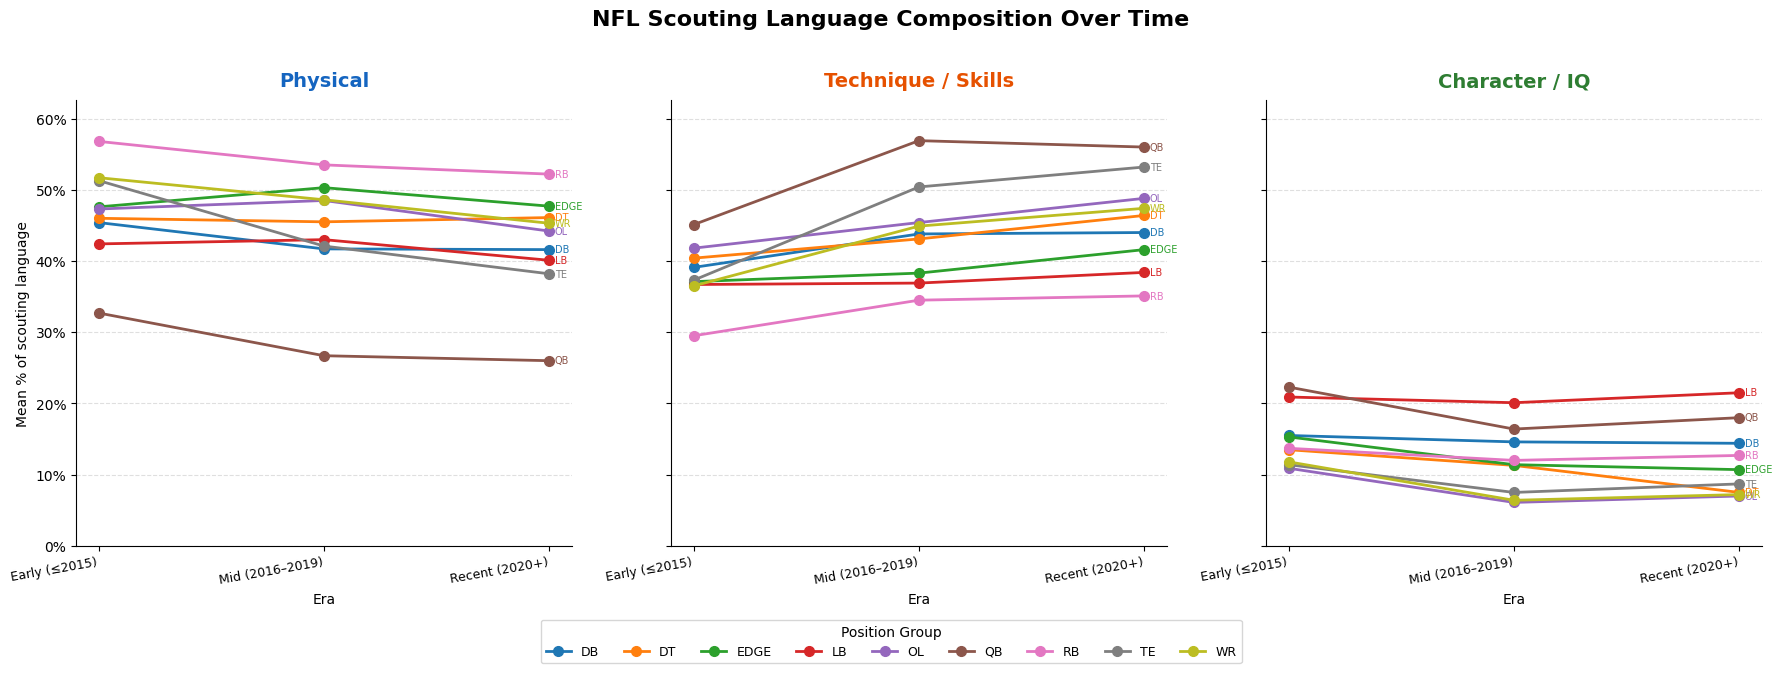

Chart saved -> ../data/processed/bin_trends_by_era.png


In [170]:
# ── 3-panel line chart — one panel per bin ──────────────────────────────────────
BIN_COLS   = ['physical_pct',  'technique_pct',    'character_pct']
BIN_TITLES = ['Physical',      'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']   # deep blue, deep orange, deep green

pos_groups = sorted(era_pos['Pos_Group'].unique())

# Assign a consistent color per position group across all 3 panels
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

# 1. CHANGED: set sharey=True for consistent scaling across panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 2. OPTIONAL: Calculate a global max to ensure the labels have breathing room
global_max = era_pos[BIN_COLS].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    for pg in pos_groups:
        sub = (era_pos[era_pos['Pos_Group'] == pg]
               .sort_values('era_order'))
        if sub.empty:
            continue
        ax.plot(
            sub['era'], sub[col],
            marker='o', linewidth=2, markersize=7,
            color=pg_colors[pg], label=pg,
        )
        # Label the last point with pos group name
        last = sub.iloc[-1]
        ax.annotate(
            pg,
            xy=(last['era'], last[col]),
            xytext=(4, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg],
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=10)
    ax.set_xlabel('Era', fontsize=10)
    
    # Only show Y label on the first plot to reduce clutter since they are shared
    if ax == axes[0]:
        ax.set_ylabel('Mean % of scouting language', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(len(ERA_LABELS)))
    ax.set_xticklabels(ERA_LABELS, rotation=10, ha='right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    
    # 3. CHANGED: Explicitly set y-limit starting at 0 and adding 10% headroom
    ax.set_ylim(bottom=0, top=global_max * 1.1)

# Shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Position Group',
    loc='lower center',
    ncol=len(pos_groups),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

plt.suptitle(
    'NFL Scouting Language Composition Over Time',
    fontsize=16, fontweight='bold', y=1.02,
)

# Use subplots_adjust to ensure title/legend/axes don't overlap with sharey
plt.tight_layout()

chart_path = '../data/processed/bin_trends_by_era.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {chart_path}')

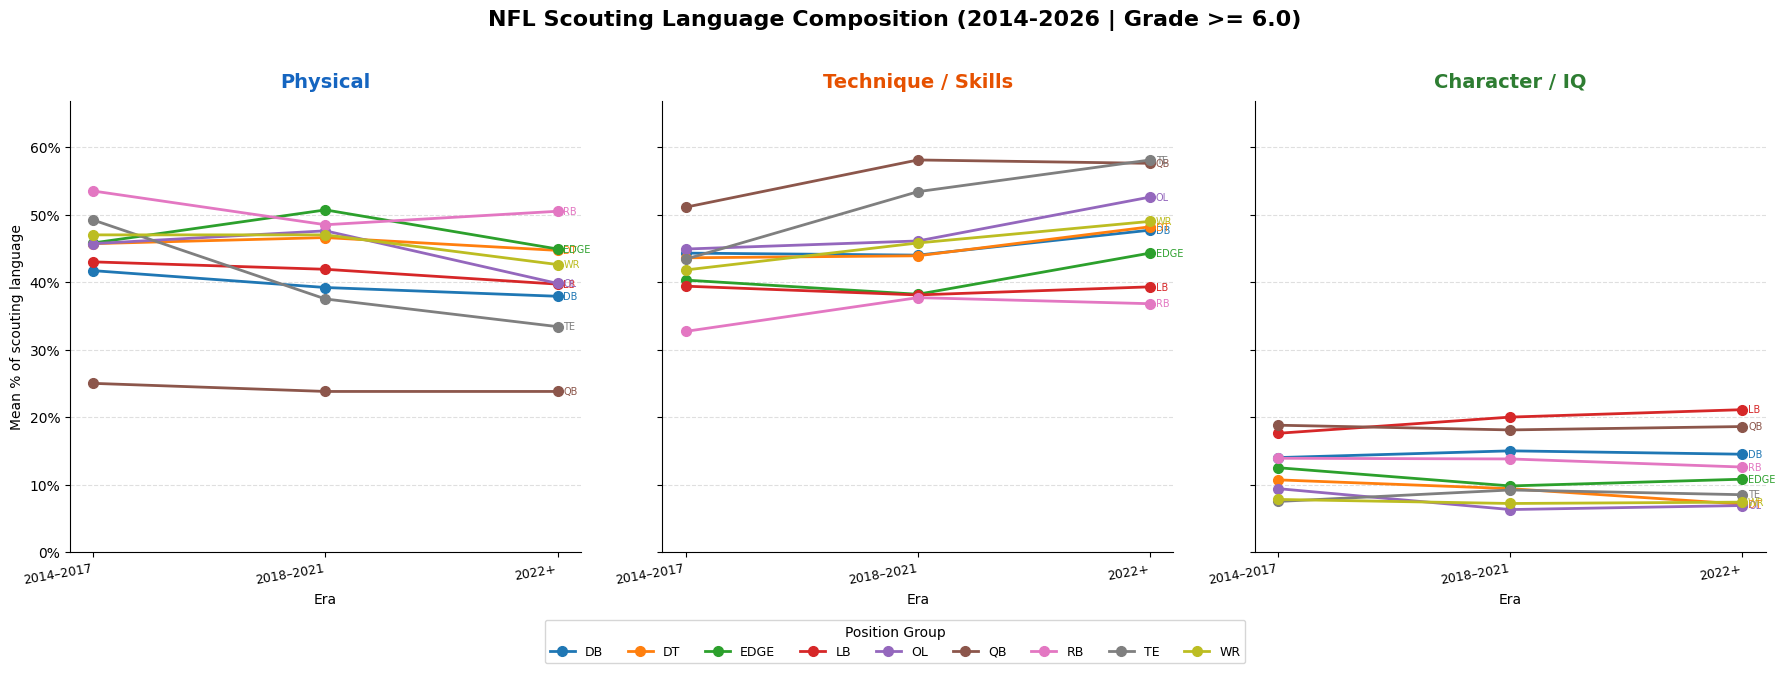

Chart saved -> ../data/processed/bin_trends_modern_high_grade.png


In [171]:
# ── Filter and Aggregate: 2014-2026 & Grade >= 6.0 ────────────────────────────
# 1. Filter raw data
mask = (df_result['year'] >= 2014) & (df_result['year'] <= 2026) & (df_result['grade'] >= 6.0)
df_filtered = df_result[mask].copy()

# 2. Define Eras for the 2014-2026 window
ERA_CUTS   = [2017, 2021] 
ERA_LABELS = [
    f'2014–{ERA_CUTS[0]}',
    f'{ERA_CUTS[0]+1}–{ERA_CUTS[1]}',
    f'{ERA_CUTS[1]+1}+'
]

def assign_era(year):
    if year <= ERA_CUTS[0]: return ERA_LABELS[0]
    elif year <= ERA_CUTS[1]: return ERA_LABELS[1]
    else: return ERA_LABELS[2]

df_filtered['era'] = df_filtered['year'].apply(assign_era)

# 3. Create era_pos aggregation
era_pos = (
    df_filtered
    .groupby(['era', 'Pos_Group'])[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .reset_index()
)

# Assign order for plotting
era_order = {label: i for i, label in enumerate(ERA_LABELS)}
era_pos['era_order'] = era_pos['era'].map(era_order)
era_pos = era_pos.sort_values(['era_order', 'Pos_Group']).reset_index(drop=True)

# ── 3-panel line chart — one panel per bin ──────────────────────────────────────
BIN_COLS   = ['physical_pct',  'technique_pct',    'character_pct']
BIN_TITLES = ['Physical',      'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']   # deep blue, deep orange, deep green

pos_groups = sorted(era_pos['Pos_Group'].unique())

# Assign a consistent color per position group across all 3 panels
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

# 1. CHANGED: set sharey=True for consistent scaling across panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 2. OPTIONAL: Calculate a global max to ensure the labels have breathing room
global_max = era_pos[BIN_COLS].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    for pg in pos_groups:
        sub = (era_pos[era_pos['Pos_Group'] == pg]
               .sort_values('era_order'))
        if sub.empty:
            continue
        ax.plot(
            sub['era'], sub[col],
            marker='o', linewidth=2, markersize=7,
            color=pg_colors[pg], label=pg,
        )
        # Label the last point with pos group name
        last = sub.iloc[-1]
        ax.annotate(
            pg,
            xy=(last['era'], last[col]),
            xytext=(4, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg],
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=10)
    ax.set_xlabel('Era', fontsize=10)
    
    # Only show Y label on the first plot to reduce clutter since they are shared
    if ax == axes[0]:
        ax.set_ylabel('Mean % of scouting language', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(len(ERA_LABELS)))
    ax.set_xticklabels(ERA_LABELS, rotation=10, ha='right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    
    # 3. CHANGED: Explicitly set y-limit starting at 0 and adding 15% headroom for labels
    ax.set_ylim(bottom=0, top=global_max * 1.15)

# Shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Position Group',
    loc='lower center',
    ncol=len(pos_groups),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

plt.suptitle(
    'NFL Scouting Language Composition (2014-2026 | Grade >= 6.0)',
    fontsize=16, fontweight='bold', y=1.02,
)

plt.tight_layout()

chart_path = '../data/processed/bin_trends_modern_high_grade.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {chart_path}')

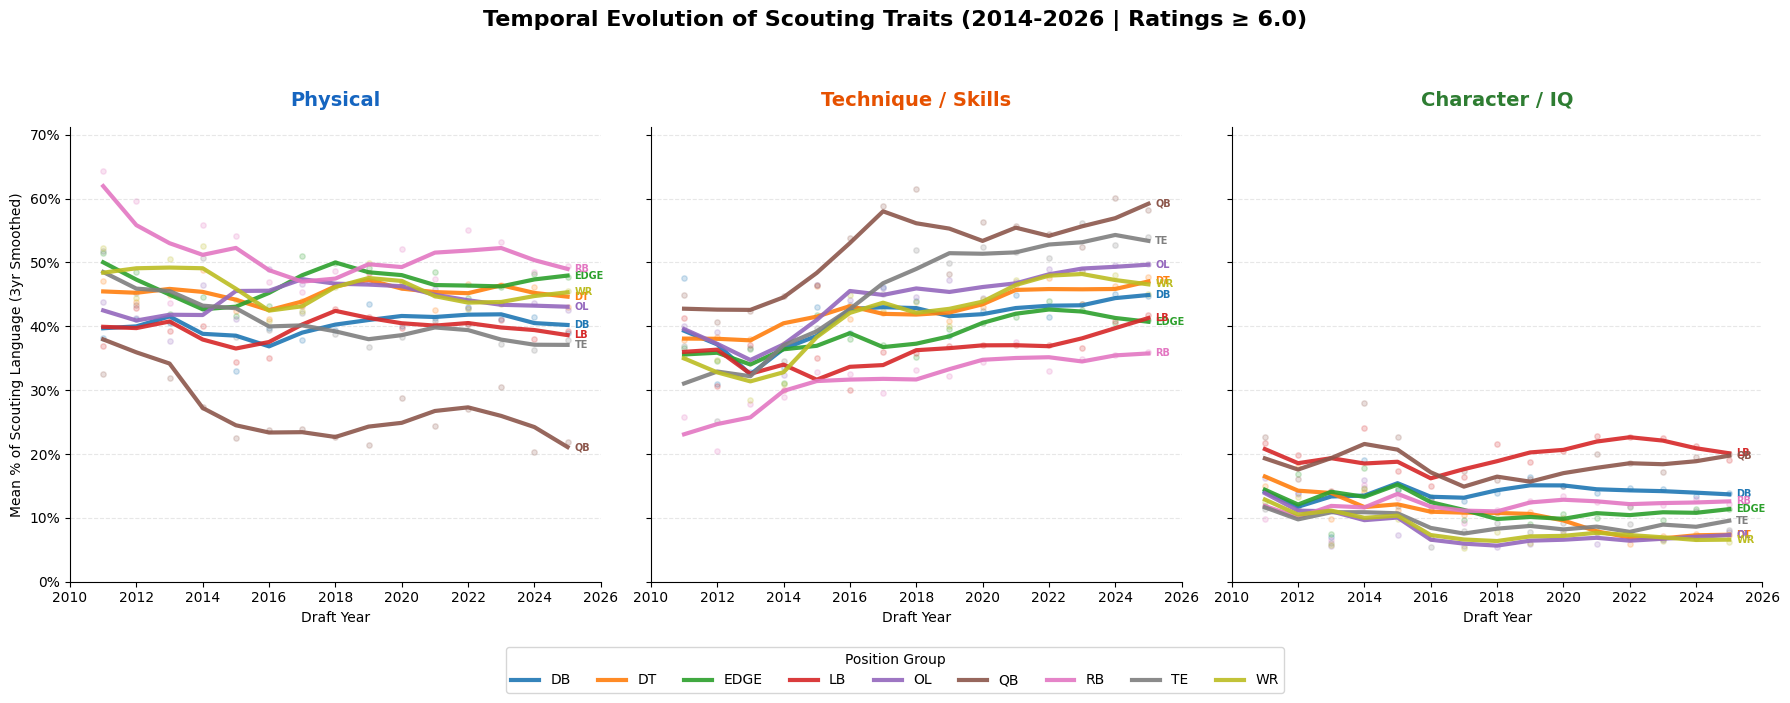

In [172]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Filter: Modern Era (2014-2026) and High-Grade Prospects (>= 6.0)
mask = (df_result['year'] >= 2011) & (df_result['year'] <= 2025) & (df_result['grade'] >= 5.5)
df_yearly = df_result[mask].copy()

# 2. Aggregate: Mean per Year per Position
# We multiply by 100 here so the smoothing happens on the percentage scale
yearly_stats = (
    df_yearly
    .groupby(['year', 'Pos_Group'])[BIN_COLS]
    .mean()
    .multiply(100)
    .reset_index()
)

# 3. Apply Smoothing (3-year rolling average per Position Group)
# min_periods=1 ensures we don't lose the start/end years (2014 and 2026)
yearly_stats = yearly_stats.sort_values(['Pos_Group', 'year'])
for col in BIN_COLS:
    yearly_stats[f'{col}_smooth'] = (
        yearly_stats.groupby('Pos_Group')[col]
        .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
    )

# ── 3-panel line chart — Yearly Smoothed ──────────────────────────────────────
BIN_TITLES = ['Physical', 'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']
pos_groups = sorted(yearly_stats['Pos_Group'].unique())

# Consistent color mapping
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Calculate global max for shared Y-axis headroom
global_max = yearly_stats[[f'{c}_smooth' for c in BIN_COLS]].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    smooth_col = f'{col}_smooth'
    
    for pg in pos_groups:
        sub = yearly_stats[yearly_stats['Pos_Group'] == pg]
        
        # Plot the smoothed line
        ax.plot(
            sub['year'], sub[smooth_col],
            marker=None, linewidth=3, alpha=0.9,
            color=pg_colors[pg], label=pg
        )
        
        # Optional: Plot the raw yearly dots at lower opacity to show the "truth"
        ax.scatter(
            sub['year'], sub[col],
            color=pg_colors[pg], s=15, alpha=0.2
        )
        
        # Annotate the final year
        last = sub.iloc[-1]
        ax.annotate(
            pg, xy=(last['year'], last[smooth_col]),
            xytext=(5, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg], fontweight='bold'
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=15)
    ax.set_xlabel('Draft Year', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Mean % of Scouting Language (3yr Smoothed)', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(2010, 2027, 2)) # Major ticks every 2 years
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Unified Y-limit with headroom
    ax.set_ylim(0, global_max * 1.15)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title='Position Group',
    loc='lower center', ncol=len(pos_groups),
    bbox_to_anchor=(0.5, -0.1), frameon=True
)

plt.suptitle(
    'Temporal Evolution of Scouting Traits (2014-2026 | Ratings ≥ 6.0)',
    fontsize=16, fontweight='bold', y=1.05
)

plt.tight_layout()
plt.show()

Source: 'strengths'  |  players: 1652  |  columns: ['str_physical_pct', 'str_technique_pct', 'str_character_pct']


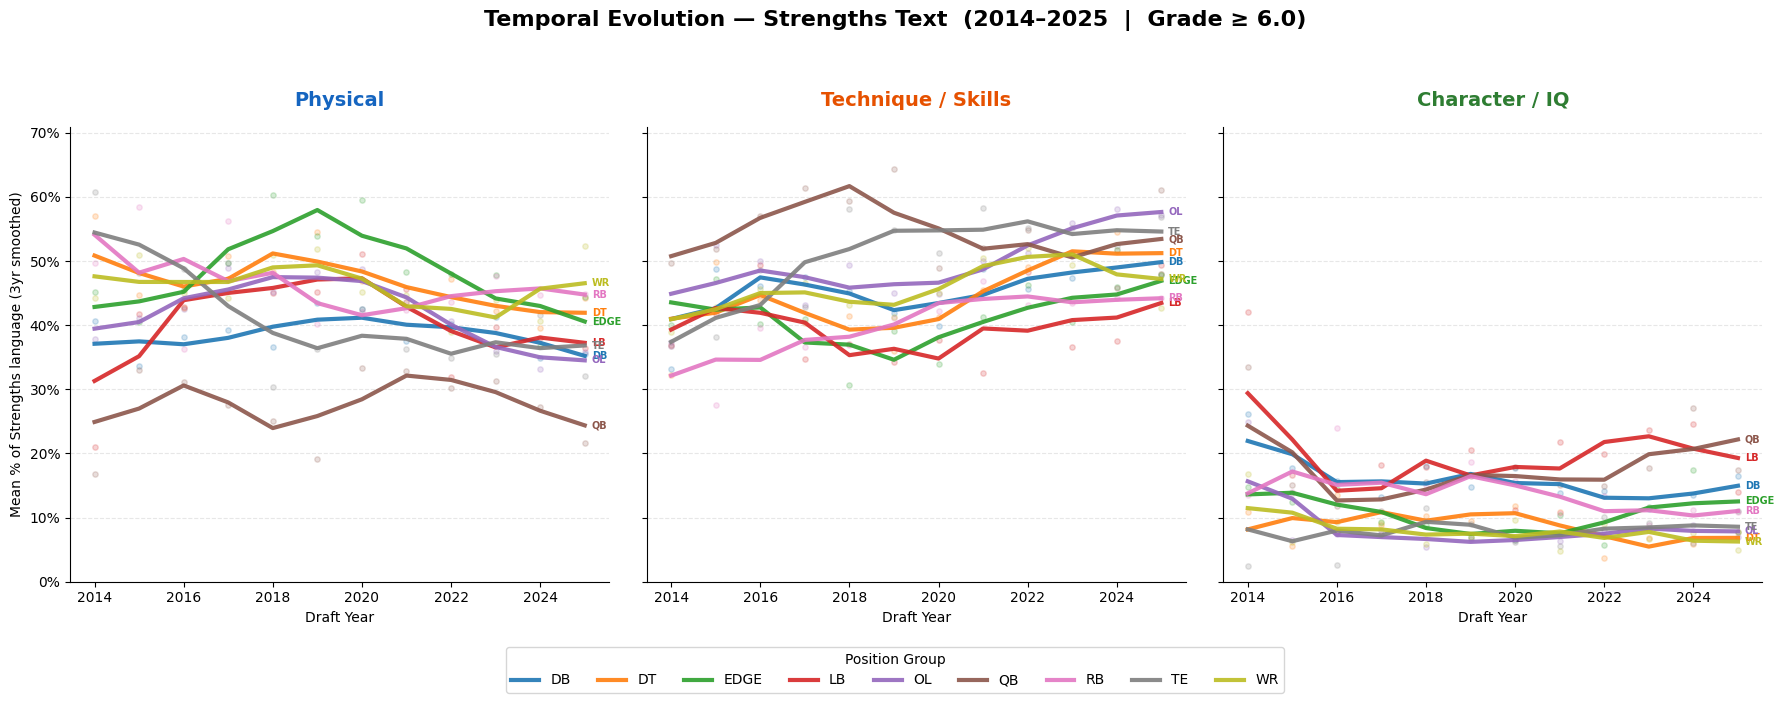

In [173]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── TOGGLE SETTINGS ───────────────────────────────────────────────────────────
TEXT_SOURCE = 'strengths'   # 'combined' | 'strengths' | 'weaknesses'
YEAR_RANGE  = (2014, 2025)
MIN_GRADE   = 6.0
# ─────────────────────────────────────────────────────────────────────────────

# Map toggle → column prefix
_PREFIX = {'combined': '', 'strengths': 'str_', 'weaknesses': 'wk_'}
if TEXT_SOURCE not in _PREFIX:
    raise ValueError(f"TEXT_SOURCE must be one of {list(_PREFIX)}, got '{TEXT_SOURCE}'")

prefix    = _PREFIX[TEXT_SOURCE]
BIN_COLS_SRC  = [f'{prefix}physical_pct', f'{prefix}technique_pct', f'{prefix}character_pct']
TOTAL_COL = f'{prefix}total_matched'

# 1. Filter
mask = (
    (df_result['year'] >= YEAR_RANGE[0]) &
    (df_result['year'] <= YEAR_RANGE[1]) &
    (df_result['grade'] >= MIN_GRADE) &
    (df_result[TOTAL_COL] > 0)          # exclude zero-match rows for this source
)
df_yearly = df_result[mask].copy()
print(f'Source: {TEXT_SOURCE!r}  |  players: {len(df_yearly)}  |  columns: {BIN_COLS_SRC}')

# 2. Aggregate: mean per year × position group
yearly_stats = (
    df_yearly
    .groupby(['year', 'Pos_Group'])[BIN_COLS_SRC]
    .mean()
    .multiply(100)
    .reset_index()
)

# 3. 3-year rolling average per position group
yearly_stats = yearly_stats.sort_values(['Pos_Group', 'year'])
for col in BIN_COLS_SRC:
    yearly_stats[f'{col}_smooth'] = (
        yearly_stats.groupby('Pos_Group')[col]
        .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
    )

# ── Chart ─────────────────────────────────────────────────────────────────────
BIN_TITLES = ['Physical', 'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']
pos_groups = sorted(yearly_stats['Pos_Group'].unique())

CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

smooth_cols = [f'{c}_smooth' for c in BIN_COLS_SRC]
global_max  = yearly_stats[smooth_cols].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS_SRC, BIN_TITLES, BIN_COLORS):
    smooth_col = f'{col}_smooth'

    for pg in pos_groups:
        sub = yearly_stats[yearly_stats['Pos_Group'] == pg]
        if sub.empty:
            continue
        ax.plot(sub['year'], sub[smooth_col], linewidth=3, alpha=0.9,
                color=pg_colors[pg], label=pg)
        ax.scatter(sub['year'], sub[col], color=pg_colors[pg], s=15, alpha=0.2)

        last = sub.iloc[-1]
        ax.annotate(pg, xy=(last['year'], last[smooth_col]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=7, va='center', color=pg_colors[pg], fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=15)
    ax.set_xlabel('Draft Year', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel(f'Mean % of {TEXT_SOURCE.title()} language (3yr smoothed)', fontsize=10)

    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(YEAR_RANGE[0], YEAR_RANGE[1] + 1, 2))
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, global_max * 1.15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Position Group', loc='lower center',
           ncol=len(pos_groups), bbox_to_anchor=(0.5, -0.1), frameon=True)

plt.suptitle(
    f'Temporal Evolution — {TEXT_SOURCE.title()} Text  '
    f'({YEAR_RANGE[0]}–{YEAR_RANGE[1]}  |  Grade ≥ {MIN_GRADE})',
    fontsize=16, fontweight='bold', y=1.05,
)
plt.tight_layout()
plt.show()

## Section 9 — Per-Position Breakdown

One figure per position group, three panels each: **Combined | Strengths | Weaknesses**.  
Within each panel, the three lines are the bins (physical, technique, character) over time.  
This lets you see how the language composition for a single position shifts, and whether strengths vs. weaknesses tell a different story.

Saved → ../data/processed/pos_breakdown_db.png


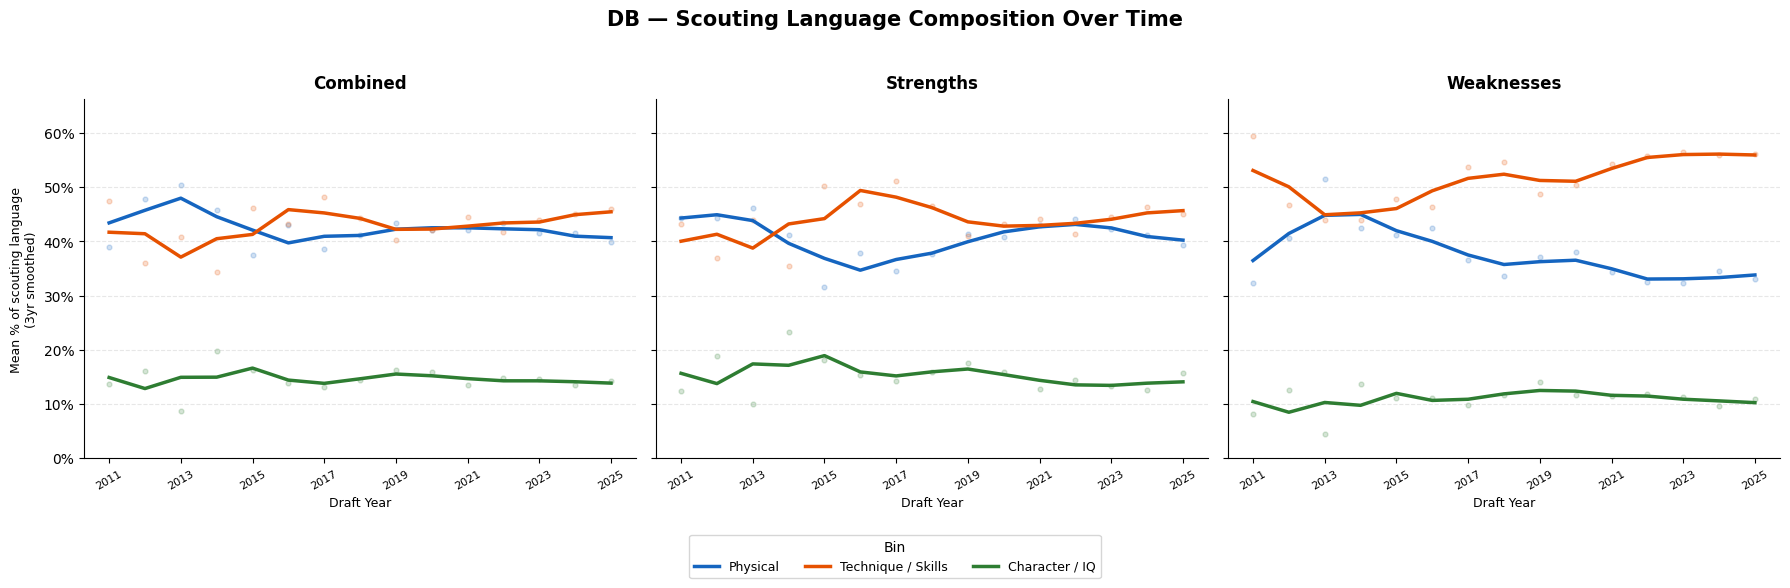

Saved → ../data/processed/pos_breakdown_dt.png


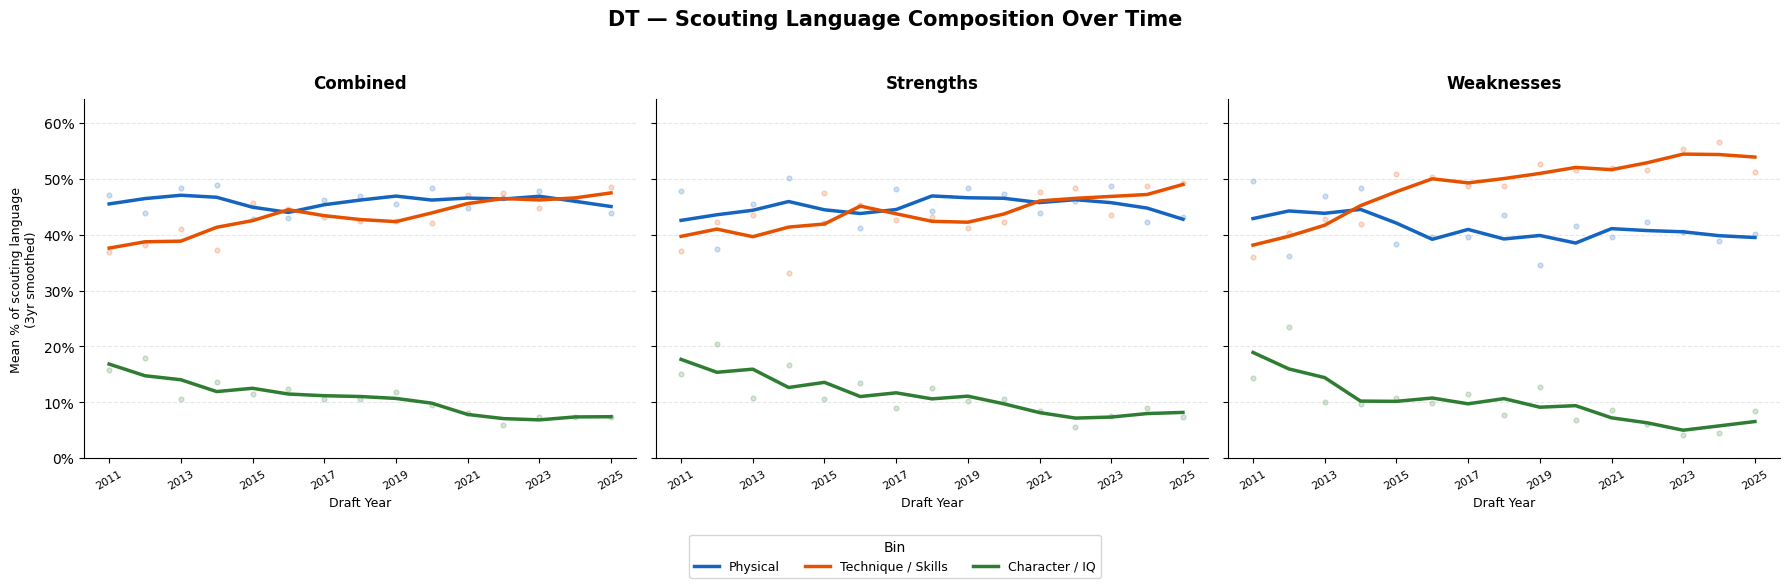

Saved → ../data/processed/pos_breakdown_edge.png


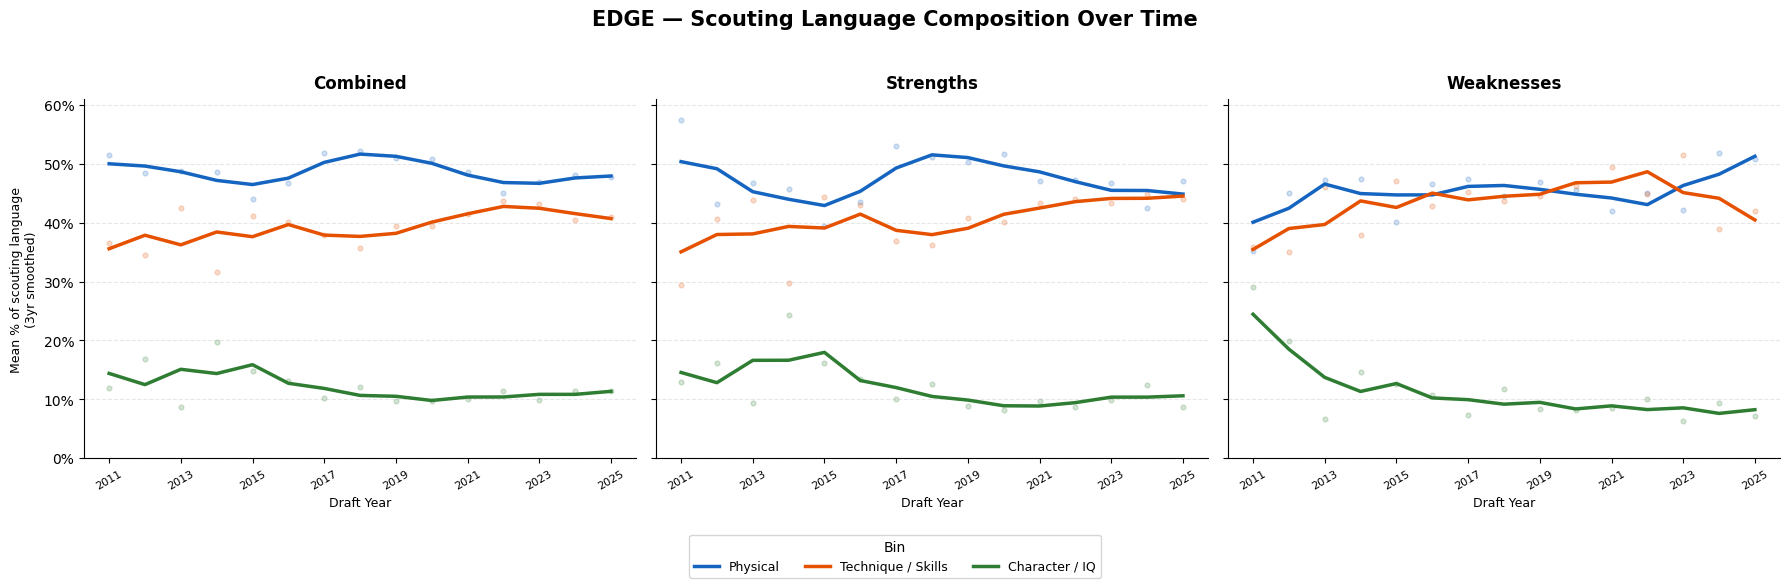

Saved → ../data/processed/pos_breakdown_lb.png


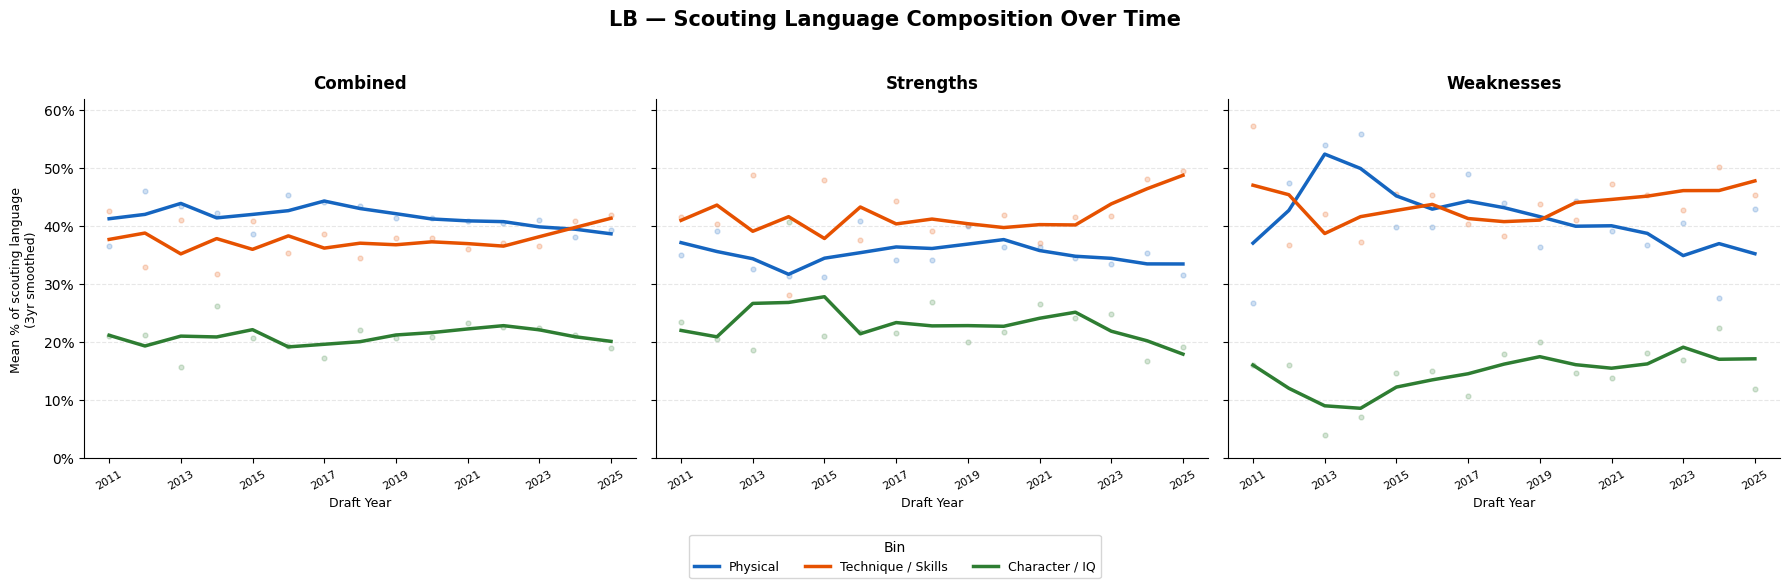

Saved → ../data/processed/pos_breakdown_ol.png


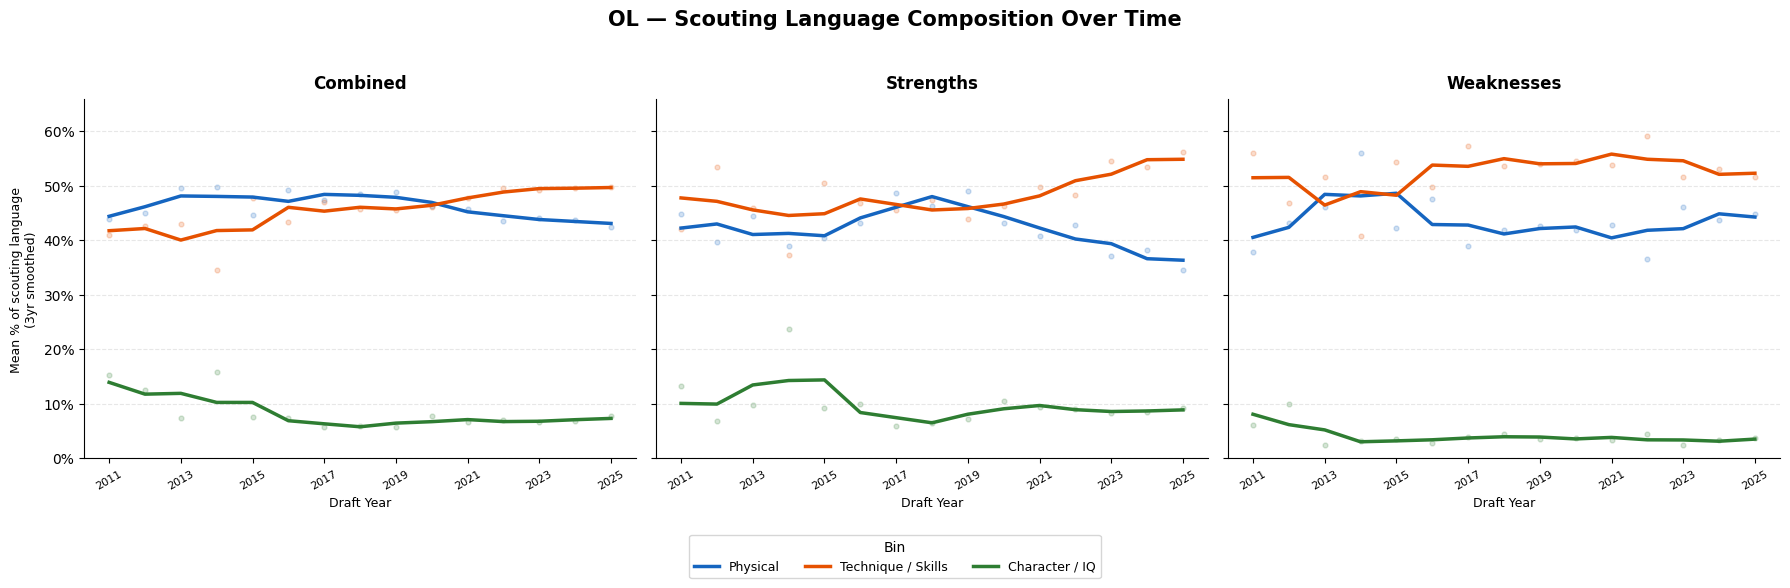

Saved → ../data/processed/pos_breakdown_qb.png


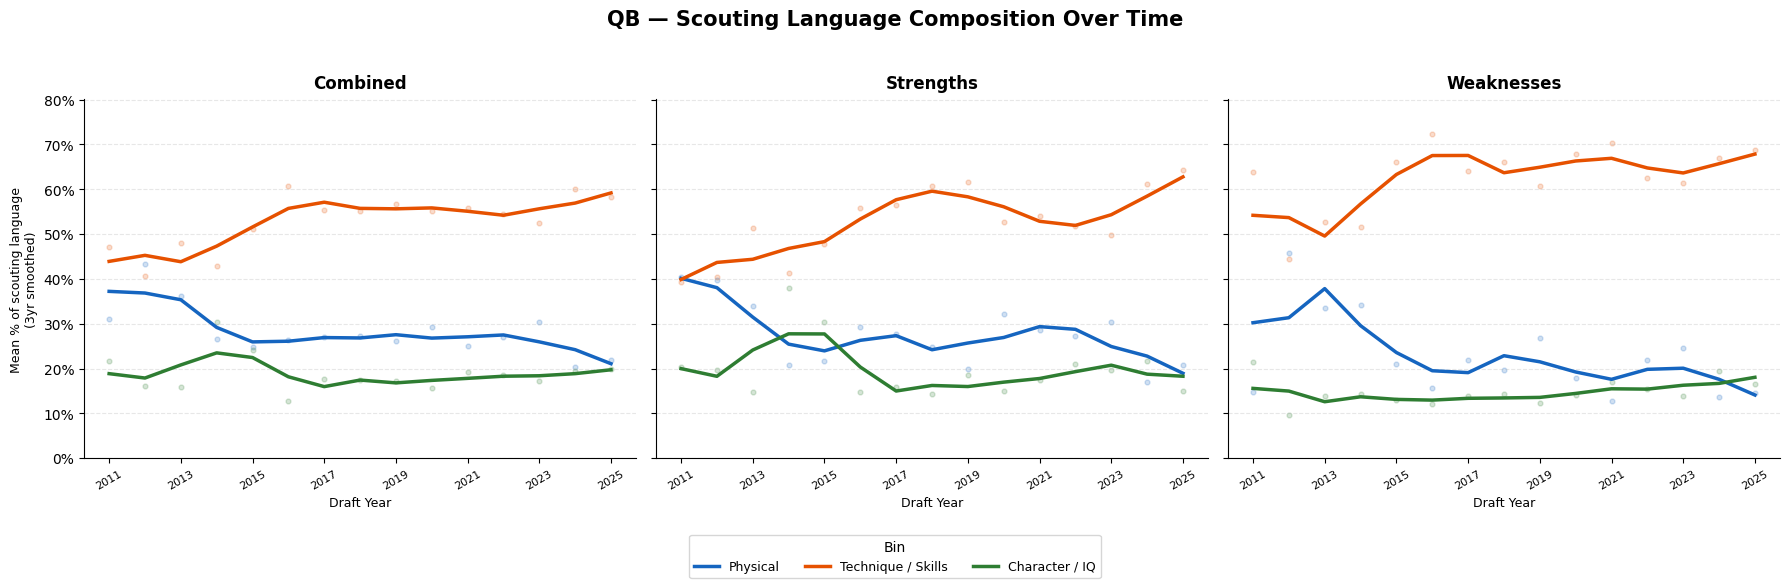

Saved → ../data/processed/pos_breakdown_rb.png


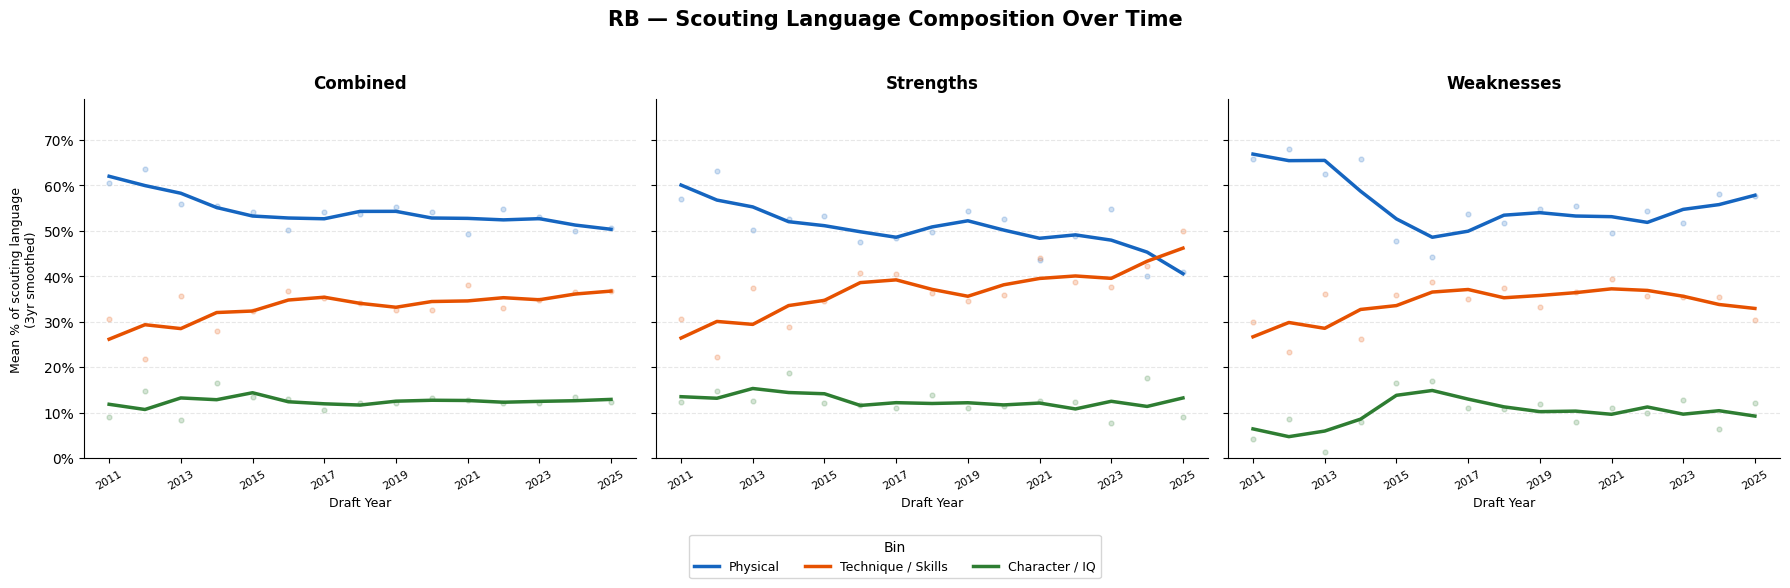

Saved → ../data/processed/pos_breakdown_te.png


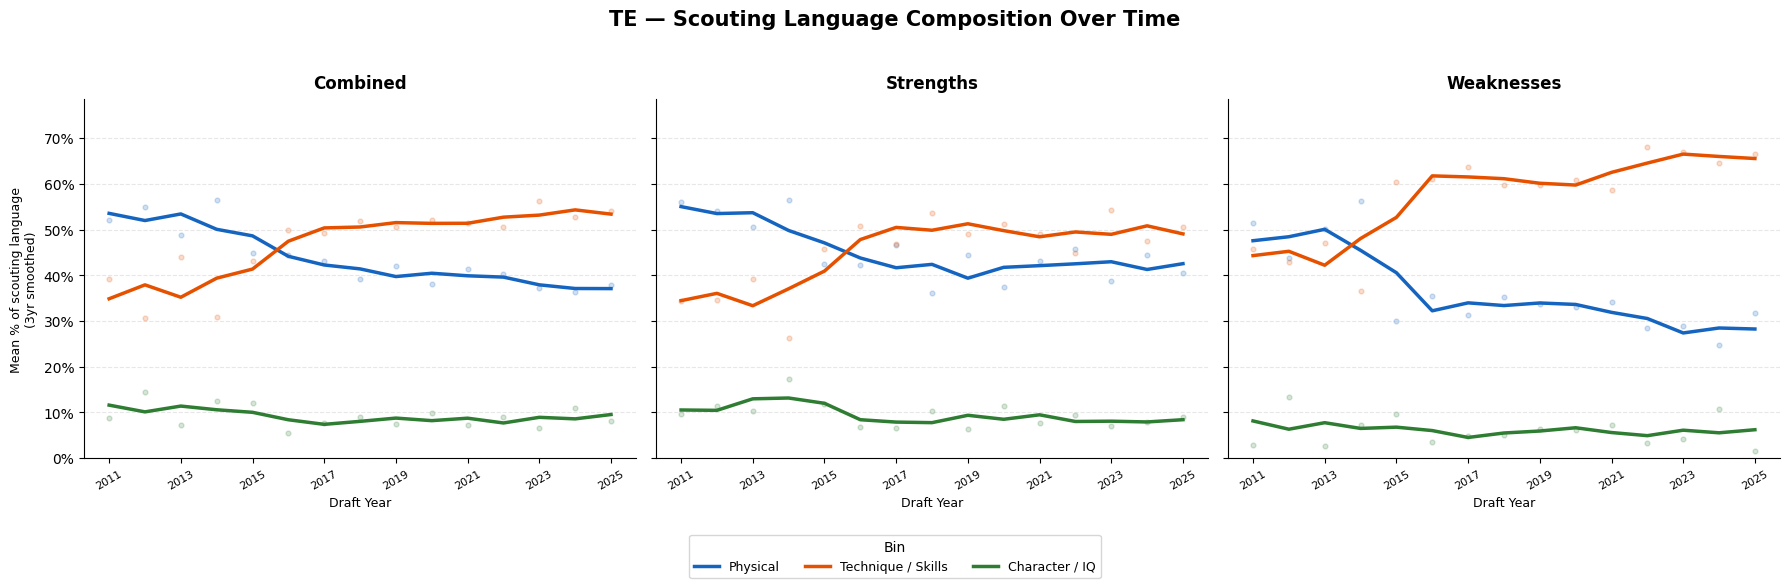

Saved → ../data/processed/pos_breakdown_wr.png


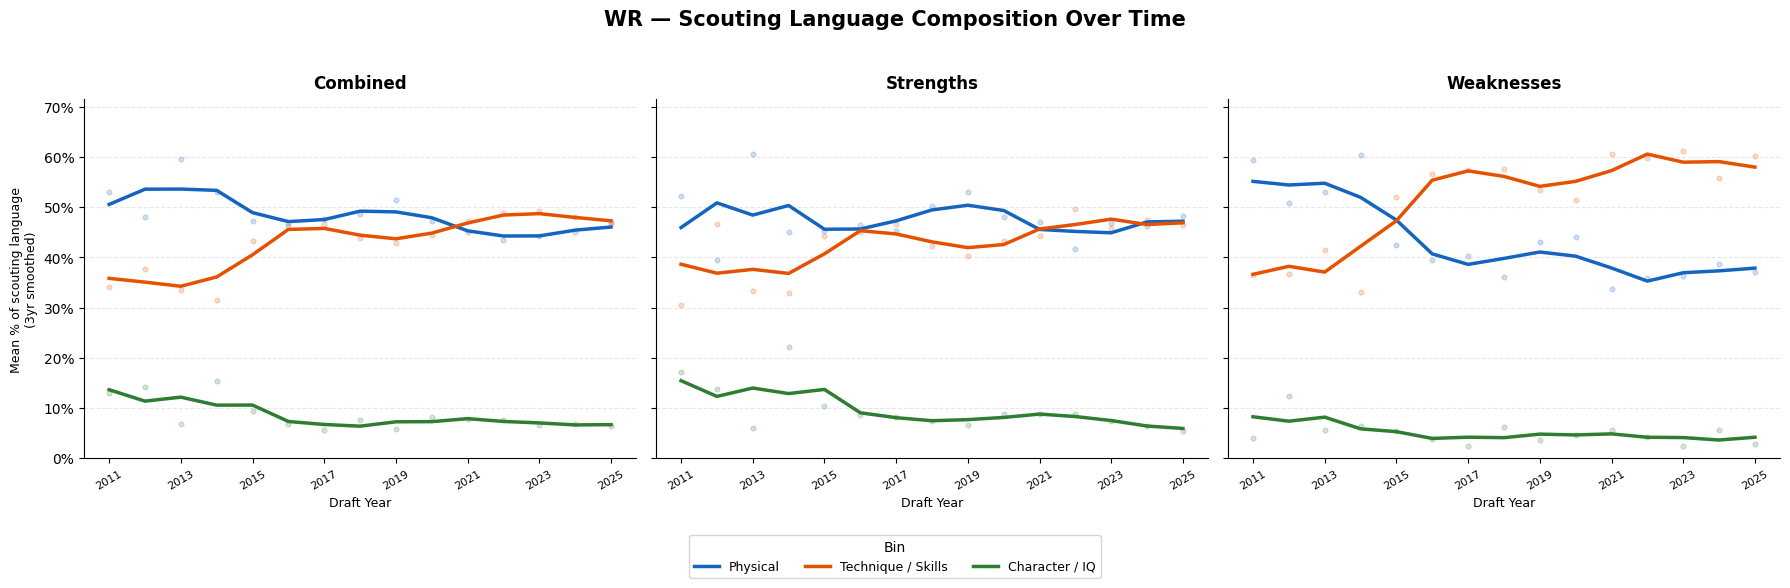

In [176]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Config ────────────────────────────────────────────────────────────────────
YEAR_RANGE    = (2011, 2025)
MIN_GRADE     = 0
SMOOTH_WINDOW = 3            # years in rolling average
SAVE_CHARTS   = True        # set True to save one PNG per position group

# Text sources: (column prefix, total_matched col, panel title)
SOURCES = [
    ('',     'total_matched',     'Combined'),
    ('str_', 'str_total_matched', 'Strengths'),
    ('wk_',  'wk_total_matched',  'Weaknesses'),
]

# Bins: (pct column suffix, display label, color)
BINS = [
    ('physical_pct',  'Physical',          '#1565C0'),
    ('technique_pct', 'Technique / Skills','#E65100'),
    ('character_pct', 'Character / IQ',    '#2E7D32'),
]

# ── Loop over positions ───────────────────────────────────────────────────────
pos_groups = sorted(df_result['Pos_Group'].dropna().unique())

for pg in pos_groups:
    base_mask = (
        (df_result['year']      >= YEAR_RANGE[0]) &
        (df_result['year']      <= YEAR_RANGE[1]) &
        (df_result['grade']     >= MIN_GRADE)      &
        (df_result['Pos_Group'] == pg)
    )
    df_pg = df_result[base_mask].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(
        f'{pg} — Scouting Language Composition Over Time',
        fontsize=15, fontweight='bold', y=1.03,
    )

    global_max = 0   # will be used to set a shared y-limit after all panels are drawn

    for ax, (prefix, total_col, panel_title) in zip(axes, SOURCES):
        # Drop players with zero keyword matches for this specific source
        df_src = df_pg[df_pg[total_col] > 0].copy()

        bin_cols = [f'{prefix}{suf}' for suf, _, _ in BINS]

        # Aggregate: mean per year
        yearly = (
            df_src
            .groupby('year')[bin_cols]
            .mean()
            .multiply(100)
            .reset_index()
            .sort_values('year')
        )

        # 3-year rolling smooth
        for col in bin_cols:
            yearly[f'{col}_smooth'] = (
                yearly[col]
                .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
                .mean()
            )

        panel_max = yearly[[f'{c}_smooth' for c in bin_cols]].max().max()
        if not np.isnan(panel_max):
            global_max = max(global_max, panel_max)

        # Draw one line per bin
        for col_suf, bin_label, color in BINS:
            col    = f'{prefix}{col_suf}'
            smooth = f'{col}_smooth'
            if col not in yearly.columns or yearly.empty:
                continue
            ax.plot(yearly['year'], yearly[smooth],
                    linewidth=2.5, color=color, label=bin_label)
            ax.scatter(yearly['year'], yearly[col],
                       color=color, s=12, alpha=0.2)

        ax.set_title(panel_title, fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Draft Year', fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel('Mean % of scouting language\n(3yr smoothed)', fontsize=9)

        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.set_xticks(range(YEAR_RANGE[0], YEAR_RANGE[1] + 1, 2))
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    # Apply shared y-limit across all three panels
    y_top = max(global_max * 1.18, 10)   # floor at 10% so empty charts still render
    for ax in axes:
        ax.set_ylim(0, y_top)

    # Shared bin legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Bin', loc='lower center',
        ncol=3, bbox_to_anchor=(0.5, -0.12),
        fontsize=9, title_fontsize=10, frameon=True,
    )

    plt.tight_layout()

    if SAVE_CHARTS:
        out = f'../data/processed/pos_breakdown_{pg.lower()}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f'Saved → {out}')

    plt.show()

## Section 10 — Scouting Report Text Colorizer

For each position group, two players are shown side by side: one from ~2013, one from ~2025.  
Words are **colored by which bin they matched**: <span style="color:#1565C0">**Physical**</span> · <span style="color:#E65100">**Technique / Skills**</span> · <span style="color:#2E7D32">**Character / IQ**</span>  
Unmatched words appear in gray. The final % bar shows the overall bin composition.

> Note: single-word matches only — compound stitched phrases (e.g. `route_running`) are not re-split here, so they'll appear gray even if semantically relevant.

In [177]:
from collections import Counter

# ── Config ─────────────────────────────────────────────────────────────────────
TOP_N        = 40    # top N uncovered tokens to show per position
MIN_FREQ     = 5     # ignore tokens appearing fewer than N times across pos group
MIN_TOKEN_LEN = 3    # skip very short tokens (noise)

# All tokens currently covered
all_covered = set().union(*KEYWORD_SETS.values())

# ── For each position group, find the most frequent uncovered tokens ────────────
print(f'{"POS":<8} {"RANK":<5} {"TOKEN":<30} {"FREQ":>6}')
print('-' * 55)

for pos_group in sorted(df['Pos_Group'].unique()):
    pos_rows = df[df['Pos_Group'] == pos_group]
    # Combine all preprocessed tokens for this position
    counter = Counter()
    for token_list in pos_rows['all_tokens']:
        if isinstance(token_list, list):
            counter.update(token_list)
    
    # Filter: not covered, long enough, frequent enough
    candidates = [
        (tok, freq) for tok, freq in counter.most_common()
        if tok not in all_covered
        and len(tok) >= MIN_TOKEN_LEN
        and freq >= MIN_FREQ
    ]
    
    print(f'\n── {pos_group} (top {TOP_N} uncovered) ──')
    for rank, (tok, freq) in enumerate(candidates[:TOP_N], 1):
        print(f'  {rank:<4} {tok:<35} {freq:>5}')


POS      RANK  TOKEN                            FREQ
-------------------------------------------------------


TypeError: '<' not supported between instances of 'float' and 'str'

In [178]:
from IPython.display import display, HTML
import re as _re

# ── Config ─────────────────────────────────────────────────────────────────────
EARLY_YR   = 2013    # strictly 2013
LATE_YR    = 2025    # strictly 2025
EARLY_POOL = [2013, 2014]          # allow one year buffer for early
LATE_POOL  = [2024, 2025]          # allow one year buffer for late
MIN_GRADE  = 6.0

# Which text sections to display
SHOW_SECTIONS = ['overview', 'strengths', 'weaknesses']

# ── Palette (matches existing notebook) ────────────────────────────────────────
_BIN_COLOR = {
    'physical':  '#1565C0',
    'technique': '#E65100',
    'character': '#2E7D32',
    'none':      '#AAAAAA',
}
_BIN_LABEL = {
    'physical':  'Physical',
    'technique': 'Technique / Skills',
    'character': 'Character / IQ',
}

# ── Build phrase → bin lookup from CURATED_PHRASE_MAP ─────────────────────────
# Maps e.g. "route running" → ('technique', 'route_running')
_PHRASE_BIN = {}
for raw_phrase, stitched in CURATED_PHRASE_MAP.items():
    for bin_name, kws in KEYWORD_SETS.items():
        if stitched in kws:
            _PHRASE_BIN[raw_phrase.lower()] = (bin_name, stitched)
            break

# Sort longest-first so greedy matching picks "route running" before "route"
_PHRASE_LIST = sorted(_PHRASE_BIN.keys(), key=len, reverse=True)

# ── Colorize raw text ──────────────────────────────────────────────────────────
def _bin_of_word(word: str) -> str:
    token = lemmatizer.lemmatize(word.lower())
    for bn, kws in KEYWORD_SETS.items():
        if token in kws:
            return bn
    return 'none'

def _span(text: str, bin_name: str) -> str:
    c = _BIN_COLOR[bin_name]
    w = 'bold' if bin_name != 'none' else 'normal'
    return f'<span style="color:{c};font-weight:{w}">{text}</span>'

def _colorize(raw_text: str) -> str:
    if not isinstance(raw_text, str) or not raw_text.strip():
        return '<em style="color:#666">—</em>'

    # Work on a lowercased copy for matching, but emit original chars
    text    = raw_text
    lo_text = raw_text.lower()
    parts   = []
    i       = 0

    while i < len(text):
        # 1. Try multi-word phrase match first
        matched_phrase = False
        for phrase in _PHRASE_LIST:
            if lo_text.startswith(phrase, i):
                bin_name = _PHRASE_BIN[phrase][0]
                parts.append(_span(text[i:i+len(phrase)], bin_name))
                i += len(phrase)
                matched_phrase = True
                break
        if matched_phrase:
            continue

        # 2. Non-word character — pass through as-is
        if not text[i].isalpha() and text[i] != "'":
            parts.append(text[i])
            i += 1
            continue

        # 3. Single word
        m = _re.match(r"[\w']+", text[i:])
        if m:
            word = m.group()
            parts.append(_span(word, _bin_of_word(word)))
            i += len(word)
        else:
            parts.append(text[i])
            i += 1

    return ''.join(parts)

# ── One player card ────────────────────────────────────────────────────────────
def _section_html(title: str, raw: str) -> str:
    if not isinstance(raw, str) or not raw.strip():
        return ''
    return (
        f'<p style="margin:10px 0 3px 0;font-size:11px;font-weight:700;'
        f'text-transform:uppercase;letter-spacing:.06em;color:#888">{title}</p>'
        f'<p style="margin:0 0 12px 0;font-size:13px;line-height:1.75">{_colorize(raw)}</p>'
    )

def _player_card(row) -> str:
    name  = row['player_name']
    pos   = row.get('position', row.get('Pos_Group', ''))
    yr    = int(row['year'])
    grade = row.get('grade', 'N/A')
    if isinstance(grade, float) and grade == grade:
        grade = f'{grade:.2f}'

    p_pct = float(row['physical_pct'])  * 100
    t_pct = float(row['technique_pct']) * 100
    c_pct = float(row['character_pct']) * 100

    bar = ''.join(
        f'<div style="display:inline-block;width:{pct:.1f}%;background:{_BIN_COLOR[b]};'
        f'height:12px" title="{_BIN_LABEL[b]}: {pct:.1f}%"></div>'
        for b, pct in [('physical', p_pct), ('technique', t_pct), ('character', c_pct)]
    )
    legend = ''.join(
        f'<span style="display:inline-block;margin-right:16px;font-size:12px">'
        f'<span style="background:{_BIN_COLOR[b]};color:#fff;padding:2px 7px;'
        f'border-radius:3px;font-size:11px">{_BIN_LABEL[b]}</span>&nbsp;{pct:.1f}%</span>'
        for b, pct in [('physical', p_pct), ('technique', t_pct), ('character', c_pct)]
    )

    body = ''.join(_section_html(s.capitalize(), row.get(s, '')) for s in SHOW_SECTIONS)

    return f"""
    <div style="border:1px solid #444;border-radius:8px;padding:18px 22px;
                margin:10px 0;font-family:'Segoe UI',Arial,sans-serif;max-width:900px">
      <div style="display:flex;justify-content:space-between;align-items:baseline;
                  border-bottom:2px solid #444;padding-bottom:8px;margin-bottom:14px">
        <span style="font-size:17px;font-weight:700">{name}</span>
        <span style="font-size:12px;color:#999">{pos} &nbsp;·&nbsp; {yr} Draft &nbsp;·&nbsp; Grade&nbsp;{grade}</span>
      </div>
      {body}
      <div style="margin-top:14px;border-top:1px solid #444;padding-top:10px">
        <div style="width:100%;border-radius:4px;overflow:hidden;margin-bottom:7px">{bar}</div>
        {legend}
      </div>
    </div>"""

# ── Merge text back onto df_result ─────────────────────────────────────────────
_text_cols = ['player_name'] + SHOW_SECTIONS
_df_vis = df_result.merge(
    df[_text_cols].drop_duplicates('player_name'),
    on='player_name', how='left'
)

# ── Player selection ───────────────────────────────────────────────────────────
def _pick_pair(grp):
    """Return (early_row, late_row): grade >= MIN_GRADE, most contrasting physical_pct."""
    grp = grp[grp['grade'] >= MIN_GRADE]
    early_pool = grp[grp['year'].isin(EARLY_POOL)]
    late_pool  = grp[grp['year'].isin(LATE_POOL)]
    if early_pool.empty or late_pool.empty:
        return None, None
    best_diff, best_e, best_l = -1, None, None
    for _, e in early_pool.iterrows():
        for _, l in late_pool.iterrows():
            diff = abs(float(e['physical_pct']) - float(l['physical_pct']))
            if diff > best_diff:
                best_diff, best_e, best_l = diff, e, l
    return best_e, best_l

# ── Render ──────────────────────────────────────────────────────────────────────
html_out = []
skipped  = []

for pos_group, grp in _df_vis.groupby('Pos_Group'):
    early, late = _pick_pair(grp)
    if early is None:
        skipped.append(pos_group)
        continue
    html_out.append(
        f'<h2 style="font-family:\'Segoe UI\',Arial,sans-serif;margin:36px 0 4px 0;'
        f'font-size:15px;font-weight:700;color:#ccc;border-bottom:2px solid #444;'
        f'padding-bottom:4px">{pos_group}</h2>'
    )
    html_out.append(_player_card(early))
    html_out.append(_player_card(late))

if skipped:
    html_out.append(f'<p style="font-family:sans-serif;color:#888;font-size:12px">'
                    f'Skipped (no grade ≥{MIN_GRADE} players in {EARLY_POOL}/{LATE_POOL}): '
                    f'{", ".join(skipped)}</p>')

display(HTML('\n'.join(html_out)))
